# we now have our striped model let's evaluate it!

In [1]:
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
from evals.evals_utils_joint import Evals
evals = Evals('/data1/lesliec/sarthak/caduceus/outputs/2026-04-14/17-23-24-651827/checkpoints/01-step=16000.ckpt')
evals.backbone

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=2, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>
JointMaskingDecoder: d_model=128, d_output1=5, d_output2=1, upsample=1


DNAEmbeddingModelStriped(
  (backbone): StripedMambaBackbone(
    (conv_block): ConvBlock(
      (norm): RMSBatchNorm1d()
      (act): GELU(approximate='none')
      (op): StandardizedConv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    )
    (global_down): DownsampleStack(
      (layers): ModuleList(
        (0): DownsampleLayer(
          (downres_increase): ConvBlock(
            (norm): RMSBatchNorm1d()
            (act): GELU(approximate='none')
            (op): StandardizedConv1d(128, 192, kernel_size=(5,), stride=(1,), padding=(2,))
          )
          (downres_refine): ConvBlock(
            (norm): RMSBatchNorm1d()
            (act): GELU(approximate='none')
            (op): StandardizedConv1d(192, 192, kernel_size=(5,), stride=(1,), padding=(2,))
          )
          (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
        (1): DownsampleLayer(
          (downres_increase): ConvBlock(
            (norm): RMSBatchNo

In [2]:
#let's plot it
s,a,s_u,a_u = evals(0)
print(s.shape, a.shape, s_u.shape, a_u.shape)

/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:177: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


torch.Size([1, 2097152, 5]) torch.Size([1, 2097152, 1]) torch.Size([2097152, 6]) torch.Size([2097152, 2])


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

In [ ]:
a_u.sum(0) #look at second value, you see it's roughly 1/4 so that means 1 means it's masked

tensor([103773.3438, 532500.0000])

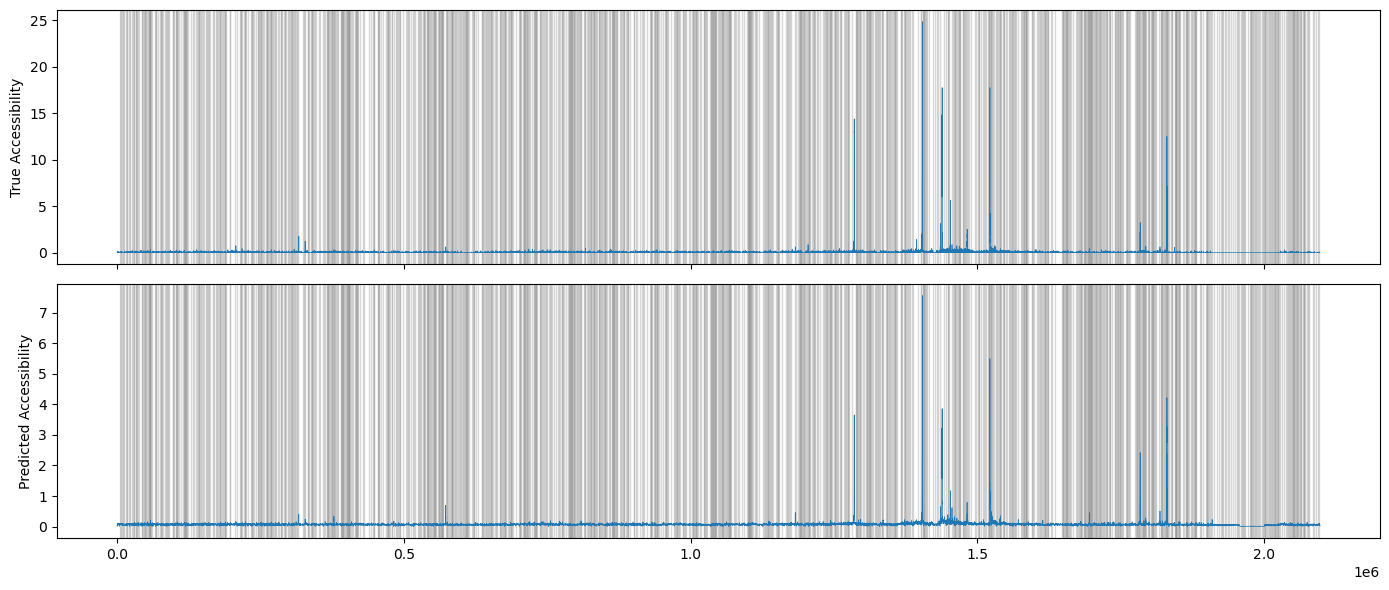

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import torch

true_acc = a_u[:, 0].numpy()
mask = a_u[:, 1].numpy().astype(bool)
pred_acc = a.squeeze().cpu().to(torch.float32).numpy()

# find contiguous masked regions efficiently
transitions = np.diff(mask.astype(int), prepend=0, append=0)
starts = np.where(transitions == 1)[0]
ends = np.where(transitions == -1)[0]

x = np.arange(len(true_acc))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(x, true_acc, linewidth=0.5)
axes[0].set_ylabel('True Accessibility')

axes[1].plot(x, pred_acc, linewidth=0.5)
axes[1].set_ylabel('Predicted Accessibility')

for ax in axes:
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, alpha=0.3, color='gray')

plt.tight_layout()
plt.show()

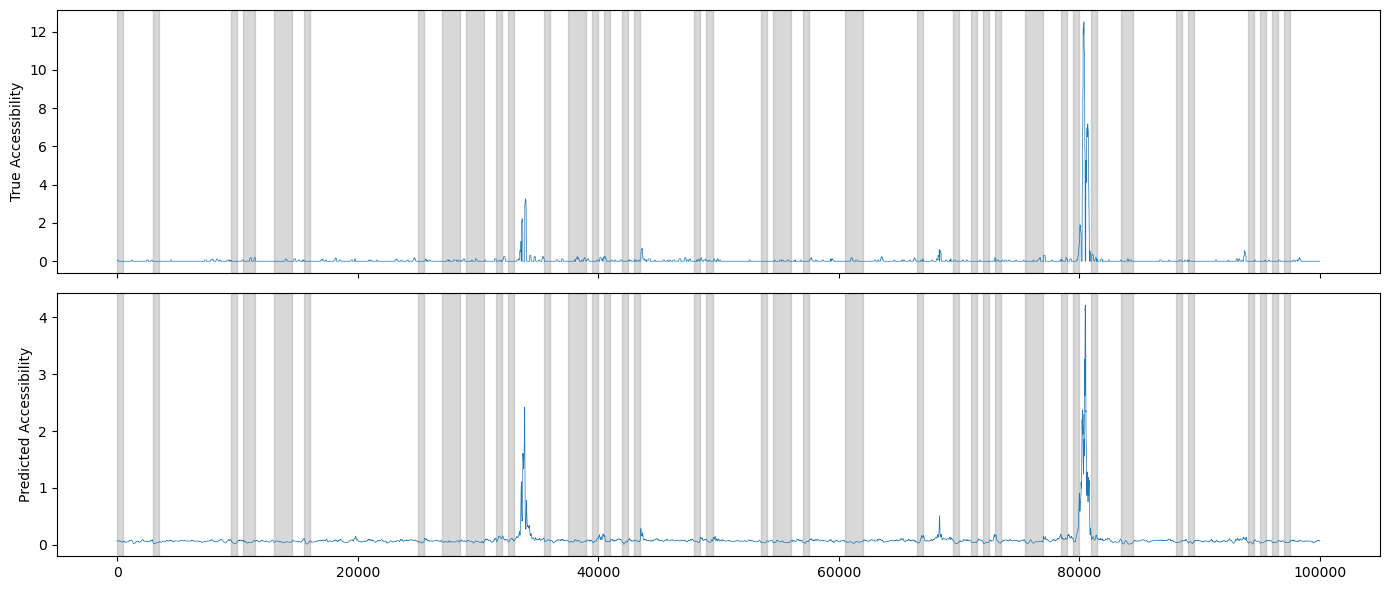

In [13]:
#let's focus on a few values
start = 1_750_000
end = 1_850_000
true_acc = a_u[start:end, 0].numpy()
mask = a_u[start:end, 1].numpy().astype(bool)
pred_acc = a.squeeze().cpu().to(torch.float32).numpy()[start:end]

# find contiguous masked regions efficiently
transitions = np.diff(mask.astype(int), prepend=0, append=0)
starts = np.where(transitions == 1)[0]
ends = np.where(transitions == -1)[0]

x = np.arange(len(true_acc))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(x, true_acc, linewidth=0.5)
axes[0].set_ylabel('True Accessibility')

axes[1].plot(x, pred_acc, linewidth=0.5)
axes[1].set_ylabel('Predicted Accessibility')

for ax in axes:
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, alpha=0.3, color='gray')

plt.tight_layout()
plt.show()

In [18]:
#the peaks somehow perfeclty are not even masked lmao!!
#let's do it again
s,a,s_u,a_u = evals(0)

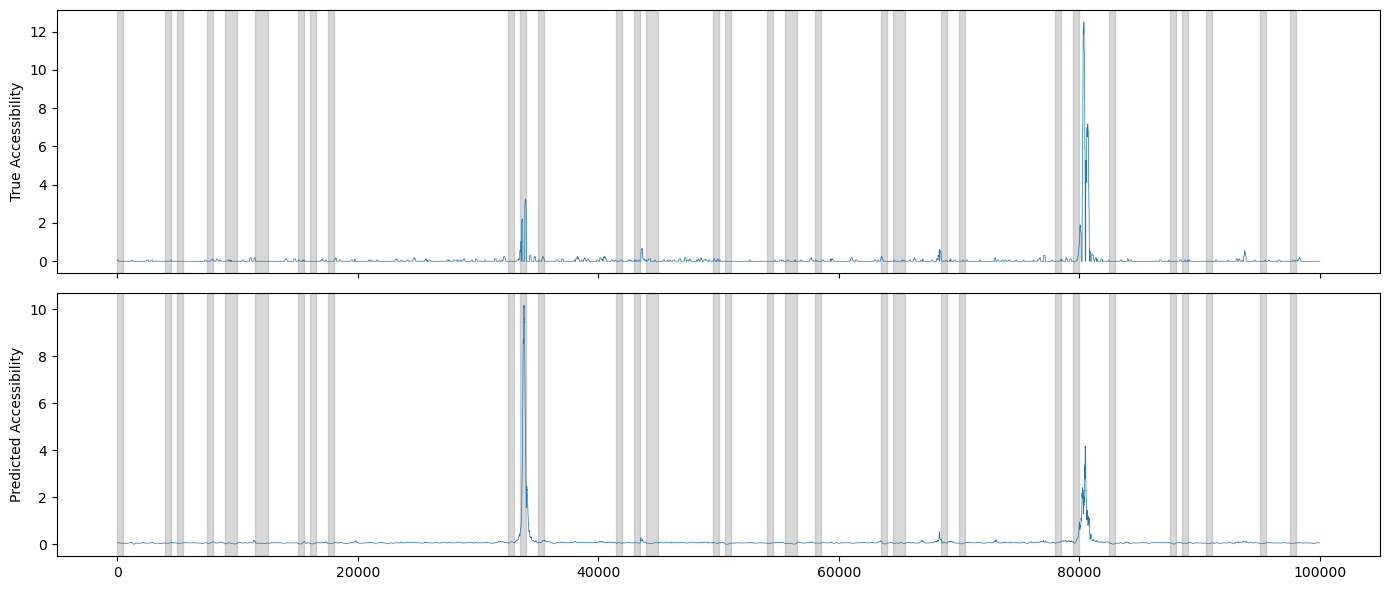

In [19]:
#let's focus on a few values
start = 1_750_000
end = 1_850_000
true_acc = a_u[start:end, 0].numpy()
mask = a_u[start:end, 1].numpy().astype(bool)
pred_acc = a.squeeze().cpu().to(torch.float32).numpy()[start:end]

# find contiguous masked regions efficiently
transitions = np.diff(mask.astype(int), prepend=0, append=0)
starts = np.where(transitions == 1)[0]
ends = np.where(transitions == -1)[0]

x = np.arange(len(true_acc))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(x, true_acc, linewidth=0.5)
axes[0].set_ylabel('True Accessibility')

axes[1].plot(x, pred_acc, linewidth=0.5)
axes[1].set_ylabel('Predicted Accessibility')

for ax in axes:
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, alpha=0.3, color='gray')

plt.tight_layout()
plt.show()

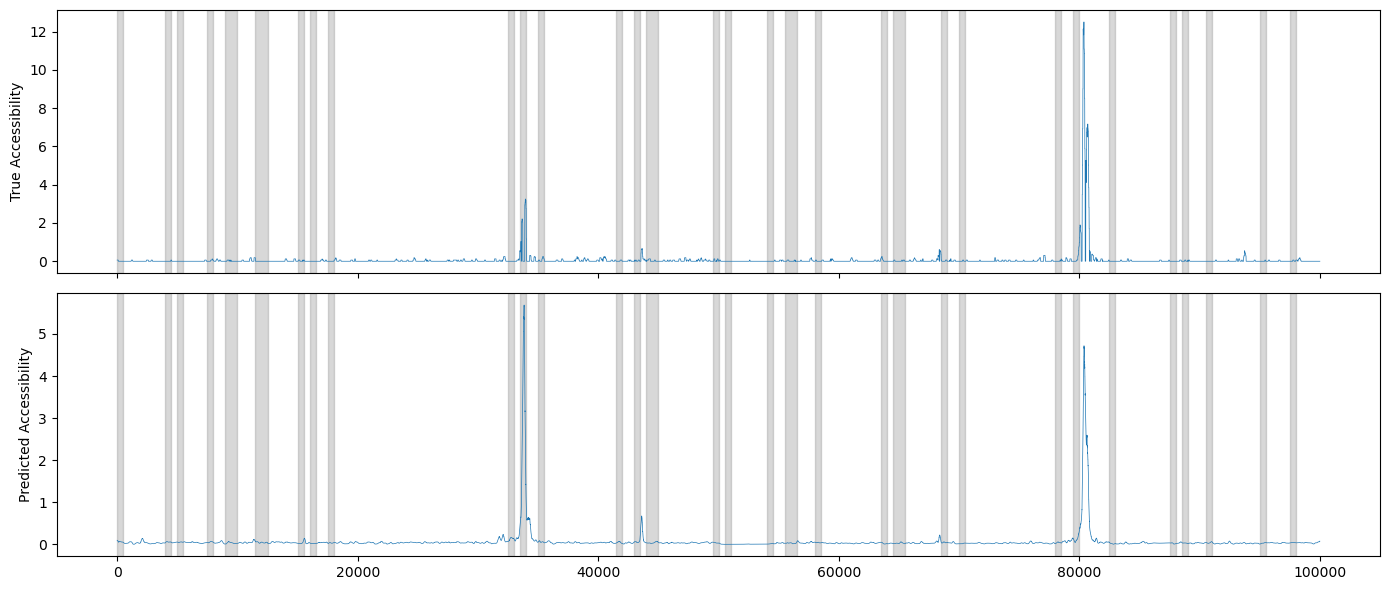

In [29]:
#let's just manually mask a region using the mask function
start = 1_750_000
end = 1_850_000
s,a,s_u,a_u,x,y = evals.mask(start+50, end-50, data=(_,_,s_u,a_u), mask_accessibility=True, ctt_val=0)
#let's focus on a few values
true_acc = a_u[start:end, 0].numpy()
mask = a_u[start:end, 1].numpy().astype(bool)
pred_acc = a.squeeze().cpu().to(torch.float32).numpy()[start:end]

# find contiguous masked regions efficiently
transitions = np.diff(mask.astype(int), prepend=0, append=0)
starts = np.where(transitions == 1)[0]
ends = np.where(transitions == -1)[0]

x = np.arange(len(true_acc))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(x, true_acc, linewidth=0.5)
axes[0].set_ylabel('True Accessibility')

axes[1].plot(x, pred_acc, linewidth=0.5)
axes[1].set_ylabel('Predicted Accessibility')

for ax in axes:
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, alpha=0.3, color='gray')

plt.tight_layout()
plt.show()

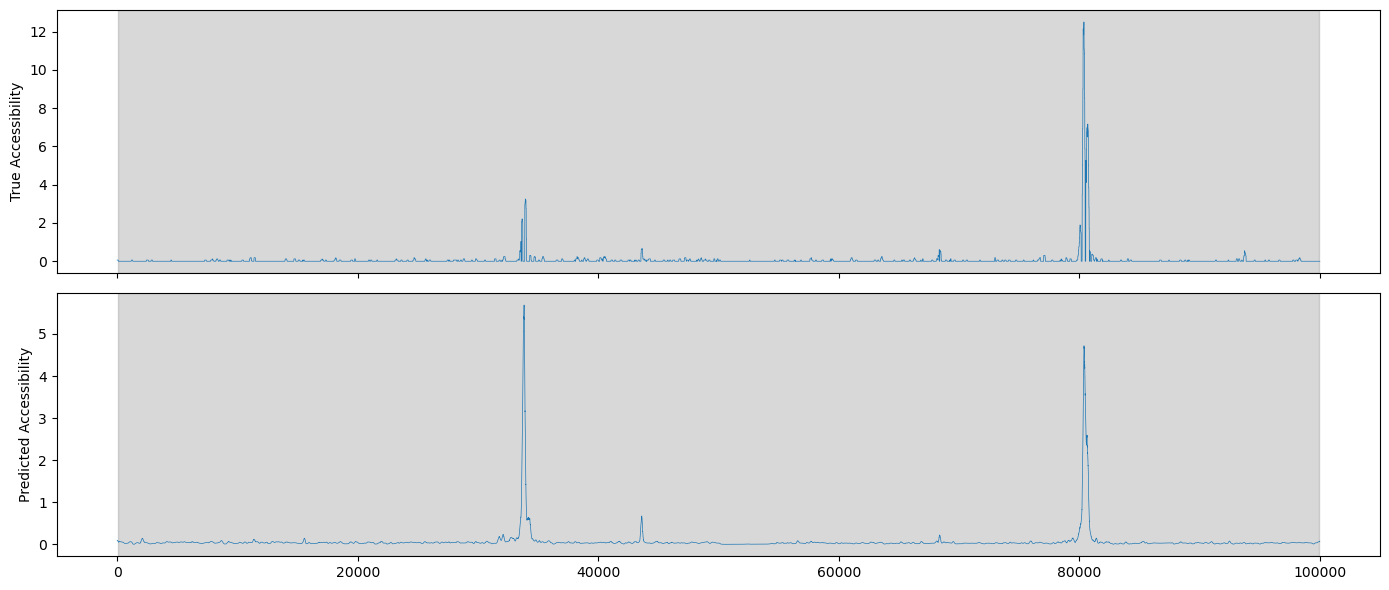

In [34]:
#oh we are masking this whole region but au isn't accounting for that. Let's look at some different cell types!
#need to use the y value actually
#let's just manually mask a region using the mask function
start = 1_750_000
end = 1_850_000
s,a,s_u,a_u,x,y = evals.mask(start+50, end-50, data=(_,_,s_u,a_u), mask_accessibility=True, ctt_val=0)
#let's focus on a few values
true_acc = a_u[start:end, 0].numpy()
mask = y.squeeze().cpu()[1,start:end].numpy().astype(bool)
pred_acc = a.squeeze().cpu().to(torch.float32).numpy()[start:end]

# find contiguous masked regions efficiently
transitions = np.diff(mask.astype(int), prepend=0, append=0)
starts = np.where(transitions == 1)[0]
ends = np.where(transitions == -1)[0]

x = np.arange(len(true_acc))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(x, true_acc, linewidth=0.5)
axes[0].set_ylabel('True Accessibility')

axes[1].plot(x, pred_acc, linewidth=0.5)
axes[1].set_ylabel('Predicted Accessibility')

for ax in axes:
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, alpha=0.3, color='gray')

plt.tight_layout()
plt.show()

In [33]:
y.shape

torch.Size([1, 2, 2097152])

In [ ]:
#clearly learning something the shape isn't perfect but learning existence of motifs and finding tiny peaks as well as the main peaks!
#actually it's probably fine, what if we just try running the dsqtl script??
d1 = evals.dataset[0]
d1[0][2] #right so first it's cell type 0 lol

tensor(0)

In [39]:
len(evals.dataset)

19370

In [ ]:
d1 = evals.dataset[1]
d1[0][2] #iterate through all sequences for one cell type. So that will mean that

tensor(0)

In [ ]:
len(evals.dataset.sequences) #yeah so 10 cell types, so 1937 will be 1, but 1936 will be 0

1937

In [42]:
d1 = evals.dataset[1936]
print(d1[0][2])
d1 = evals.dataset[1937]
print(d1[0][2])

tensor(0)
tensor(1)


In [ ]:
#what'd I say. And the cell type token is just the og index
#this can be used for the evaluations
evals.dataset.data_idxs #which one is GM12878??


array([ 96, 121, 522,  27,  12,  47,  25,   1, 198, 135])

In [45]:
import pandas as pd
dnase = pd.read_csv('/data1/lesliec/sarthak/data/DK_zarr/targets_DNase_borzoi.txt', sep='\t')
dnase

,index,identifier,file,clip,clip_soft,scale,sum_stat,description
0,0,ENCFF833POA,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:cerebellum male adult (27 years) and mal...
1,1,ENCFF110QGM,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:frontal cortex male adult (27 years) and...
2,2,ENCFF880MKD,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:chorion
3,3,ENCFF463ZLQ,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:Ishikawa treated with 0.02% dimethyl sul...
4,4,ENCFF890OGQ,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:GM03348
...,...,...,...,...,...,...,...,...
669,669,ENCFF848BGL,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:inferior parietal cortex male adult (84 ...
670,670,ENCFF403BFX,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:kidney capillary endothelial cell female...
671,671,ENCFF383SIU,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:placenta male embryo (91 day)
672,672,ENCFF253IUB,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:right kidney male embryo (115 days)


In [ ]:
#now grab the elements from idxs
dnase.iloc[evals.dataset.data_idxs] #looks exactly right. GM12878 is 12 as before!
#but that means cell type token is actually 4 because it's the 5th on this list

,index,identifier,file,clip,clip_soft,scale,sum_stat,description
96,96,ENCFF634ZUJ,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:HL-60
121,121,ENCFF413AHU,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:K562
522,522,ENCFF985WGD,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:natural killer cell male adult (21 year)
27,27,ENCFF136DBS,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:HepG2
12,12,ENCFF093VXI,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:GM12878
47,47,ENCFF688CJL,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:A549
25,25,ENCFF050BDU,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:HeLa-S3
1,1,ENCFF110QGM,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:frontal cortex male adult (27 years) and...
198,198,ENCFF678EIG,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:heart left ventricle female adult (53 ye...
135,135,ENCFF302JEV,/data1/lesliec/sarthak/data/borzoi/DNase_bigwi...,128,32,2,mean,DNASE:fibroblast of dermis female adult


In [ ]:
#so we can run this command

'''
python -u dsqtl_onemodel.py \
  -o test.npy \
  --ckpt_path /data1/lesliec/sarthak/caduceus/outputs/2026-04-14/17-23-24-651827/checkpoints/01-step=16000.ckpt \
  --mask_size 1000 \
  --data_path /data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/GM12878_DNase.npz \
  --ctt_val 4 \
  --load_data
'''

In [ ]:
#huh it errors out, let's see why the bim values could be wrong? Oh it's becausue my length differs lmao! Need length to be an argument
#ok fixed it now it's evaluating and we will compare to the ctt one! since many cell types expect it to be bad now but good when fine tuned? so maybe start finetuning early


# seems some issue with steps 16000 to 20000

In [1]:
#let's load in the evals function
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
from evals.evals_utils_joint import Evals
evals = Evals('/data1/lesliec/sarthak/caduceus/outputs/2026-04-14/17-23-24-651827/checkpoints/01-step=16000.ckpt')
evals1 = Evals('/data1/lesliec/sarthak/caduceus/outputs/2026-04-14/17-23-24-651827/checkpoints/last.ckpt')
#now get the same input for both
out = evals(0)
out1 = evals1(0)

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=2, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>
JointMaskingDecoder: d_model=128, d_output1=5, d_output2=1, upsample=1
replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=2, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>
JointMaskingDecoder: d_model=128, d_output1=5, d_output2=1, upsample=1


/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:177: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


In [2]:
len(out1)

4

In [3]:
out1[0].shape, out1[1].shape, out1[2].shape, out1[3].shape

(torch.Size([1, 2097152, 5]),
 torch.Size([1, 2097152, 1]),
 torch.Size([2097152, 6]),
 torch.Size([2097152, 2]))

In [4]:
out1[0][0,:100]

tensor([[nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, n

In [5]:
out[0][0,:100]

tensor([[-7.0190e-03,  1.9073e-03,  2.1362e-02,  1.9531e-03,  1.6861e-03],
        [-9.0332e-03,  2.6245e-03,  2.1118e-02,  1.1749e-03,  2.0981e-04],
        [-1.0193e-02,  4.1199e-03,  2.0264e-02,  1.2894e-03, -5.1117e-04],
        [-1.0254e-02,  4.0588e-03,  1.9409e-02,  1.0910e-03, -1.3580e-03],
        [-1.0742e-02,  4.1199e-03,  1.8433e-02,  8.5068e-04, -1.3809e-03],
        [-1.1047e-02,  4.3640e-03,  1.7944e-02,  7.9346e-04, -1.4114e-03],
        [-1.2085e-02,  4.6082e-03,  1.7578e-02,  6.9427e-04, -1.8768e-03],
        [-1.2634e-02,  5.2185e-03,  1.7090e-02,  3.3760e-04, -2.0447e-03],
        [-1.2939e-02,  5.4626e-03,  1.6602e-02,  3.7956e-04, -1.7700e-03],
        [-1.3184e-02,  5.4321e-03,  1.6479e-02,  4.5395e-04, -1.8234e-03],
        [-1.4099e-02,  5.8594e-03,  1.5869e-02,  1.2398e-04, -2.1057e-03],
        [-1.4160e-02,  5.9814e-03,  1.5747e-02,  1.5545e-04, -2.2278e-03],
        [-1.4954e-02,  6.3782e-03,  1.5015e-02, -1.0586e-04, -2.2583e-03],
        [-1.4893e-02,  6.

In [16]:
#let's find where the issue is, let's test backbone
idx = 0
ctt_val = None
outputs1,(seq_unmask,acc_unmask) = evals1.dataset[idx]
seq, acc = outputs1[0], outputs1[1]
if len(outputs1) > 2 and ctt_val is None:
    ctt_val = outputs1[2]

x = seq.unsqueeze(0)
y = acc.unsqueeze(0)
print(x.shape, y.shape, ctt_val)

torch.Size([1, 6, 2097152]) torch.Size([1, 2, 2097152]) tensor(0)


In [18]:
import torch
x,y = x.to(evals1.device), y.to(evals1.device)
ctt_val = torch.tensor(ctt_val).to(evals1.device).unsqueeze(0) #makes it size 1
with torch.no_grad():
    with torch.autocast(device_type=evals1.device.type, dtype=torch.bfloat16):
        x1,intermediates = evals1.encoder(x,y,ctt_token=ctt_val)

/tmp/ipykernel_3724550/3780091573.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(evals1.device).unsqueeze(0) #makes it size 1


In [19]:
intermediates

{}

In [ ]:
x1 #yeah so the encoder is fucked??

tensor([[[nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         ...,
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan]]], device='cuda:0')

In [28]:
evals.encoder

JointCNN(
  (conv): Sequential(
    (0): Conv1d(8, 128, kernel_size=(15,), stride=(1,), padding=same)
    (1): Identity()
    (2): Identity()
  )
  (ctt_embedding): Embedding(10, 128)
)

In [27]:
evals.encoder.conv[0].weight.dtype

torch.float32

In [ ]:
#so we have weights and it's float 32...
evals.encoder.ctt_embedding.weight

Parameter containing:
tensor([[ 0.0341,  0.3866, -0.3628,  ...,  0.4309, -0.0194, -0.4303],
        [ 0.1046,  0.1016, -0.0235,  ...,  0.0138, -0.2217,  0.1252],
        [ 0.2748,  0.0514, -0.0797,  ...,  0.2959, -0.0062, -0.2063],
        ...,
        [ 0.0102,  0.0404, -0.1989,  ...,  0.2871, -0.2504,  0.1827],
        [ 0.0785, -0.0626,  0.0720,  ..., -0.0176, -0.0736,  0.1613],
        [-0.1444, -0.2496,  0.0914,  ..., -0.2962,  0.0184,  0.1661]],
       device='cuda:0', requires_grad=True)

In [ ]:
print(torch.isnan(evals1.encoder.conv[0].weight).any())
#ahh some of these are nan!!

tensor(True, device='cuda:0')


In [33]:
#check embeddings
print(torch.isnan(evals1.encoder.ctt_embedding.weight).any())

tensor(True, device='cuda:0')


In [34]:
#uhh wtf? ok. 
print(torch.isnan(torch.tensor(1.0)).any())

tensor(False)


# one other thing is to look at cell type embedding (we'll use 16k for now)

In [1]:
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
from evals.evals_utils_joint import Evals
evals = Evals('/data1/lesliec/sarthak/caduceus/outputs/2026-04-14/17-23-24-651827/checkpoints/01-step=16000.ckpt')
evals.encoder.embeddings

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=2, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>
JointMaskingDecoder: d_model=128, d_output1=5, d_output2=1, upsample=1


AttributeError: 'JointCNN' object has no attribute 'embeddings'

In [3]:
evals.encoder.ctt_embedding

Embedding(10, 128)

In [5]:
evals.encoder.ctt_embedding.weight.shape

torch.Size([10, 128])

In [9]:
import json
import pandas as pd
borzoi_atac_metadata = pd.read_csv('/data1/lesliec/sarthak/data/DK_zarr/targets_DNase_borzoi.txt', sep='\t')
with open('/data1/lesliec/sarthak/data/DK_zarr/idx_lists/k562plus10.json', 'r') as f:
    idxs = json.load(f)
cell_types = [
    borzoi_atac_metadata.loc[idx, 'description'].replace('DNASE:', '').strip()
    for idx in idxs
]
cell_types

['HL-60',
 'K562',
 'natural killer cell male adult (21 year)',
 'HepG2',
 'GM12878',
 'A549',
 'HeLa-S3',
 'frontal cortex male adult (27 years) and male adult (35 years)',
 'heart left ventricle female adult (53 years)',
 'fibroblast of dermis female adult']

<Axes: >

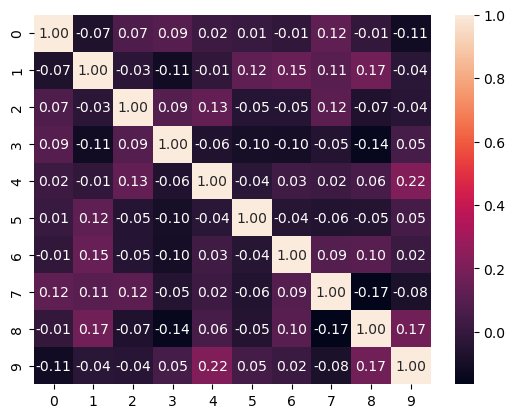

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity                                                                                                                                                                                                                                                                                                                
import seaborn as sns
import json
import pandas as pd

borzoi_atac_metadata = pd.read_csv('/data1/lesliec/sarthak/data/DK_zarr/targets_DNase_borzoi.txt', sep='\t')
with open('/data1/lesliec/sarthak/data/DK_zarr/idx_lists/k562plus10.json', 'r') as f:
    idxs = json.load(f)
cell_types = [
    borzoi_atac_metadata.loc[idx, 'description'].replace('DNASE:', '').strip()
    for idx in idxs
]

W = evals.encoder.ctt_embedding.weight.detach().cpu().numpy()  # (10, 128)                                                                                                                                                                                                                                                                                            
sim = cosine_similarity(W)
sns.heatmap(sim, annot=True, fmt=".2f")

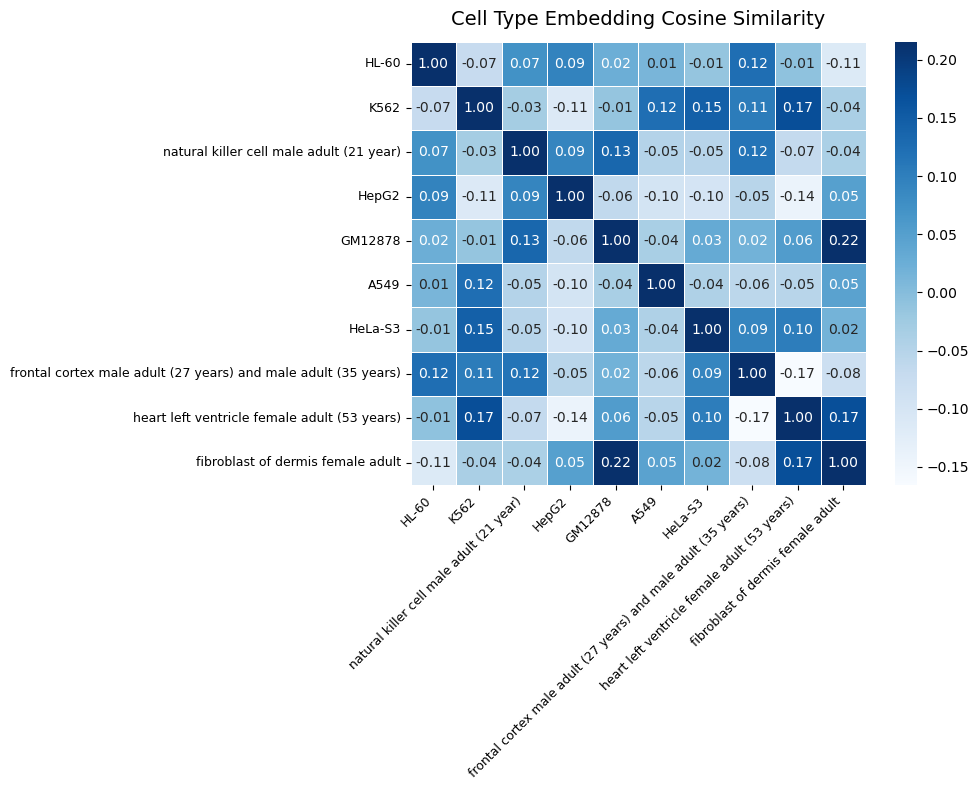

In [17]:
import numpy as np
import matplotlib.pyplot as plt
W = evals.encoder.ctt_embedding.weight.detach().cpu().numpy()                                                                                                                                                                                                                                                                                                       
sim = cosine_similarity(W)
                                                                                                                                                                                                                                                                                                                                                                    
# largest non-diagonal value
mask = ~np.eye(sim.shape[0], dtype=bool)                                                                                                                                                                                                                                                                                                                              
vmax = sim[mask].max()                                                                                                                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                                                                                                                    
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(                                                                                                                                                                                                                                                                                                                                                          
    sim,                                                                                                                                                                                                                                                                                                                                                            
    annot=True,
    fmt=".2f",
    xticklabels=cell_types,
    yticklabels=cell_types,                                                                                                                                                                                                                                                                                                                                           
    vmin=sim[mask].min(),
    vmax=vmax,                                                                                                                                                                                                                                                                                                                                                        
    cmap='Blues',                                                                                                                                                                                                                                                                                                                                                  
    linewidths=0.5,                                                                                                                                                                                                                                                                                                                                                   
    linecolor='white',
    ax=ax,                                                                                                                                                                                                                                                                                                                                                            
)                                                                                                                                                                                                                                                                                                                                                                   
ax.set_title('Cell Type Embedding Cosine Similarity', fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)                                                                                                                                                                                                                                                                                                                       
plt.yticks(rotation=0, fontsize=9)                                                                                                                                                                                                                                                                                                                                    
plt.tight_layout()                                                                                                                                                                                                                                                                                                                                                    
plt.show()

In [ ]:
#yeah this makes no sense lmao! it's fine tho we will make sure to 

# let's evaluate the expression model!

In [1]:
#it also hit nan (uh oh,)
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
from evals.evals_utils_joint import Evals
ckpt_path = "/data1/lesliec/sarthak/caduceus/outputs/2026-04-19/21-58-28-647055/checkpoints/00-step=4000.ckpt"
evals = Evals(ckpt_path)

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=None, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>


In [2]:
out = evals(0)

/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


In [3]:
out[1].shape

torch.Size([1, 1048576, 2])

In [ ]:
#see if any is nan
import torch
print(torch.isnan(out[1]).any())

tensor(True, device='cuda:0')


In [6]:
out[1]

tensor([[[nan, nan],
         [nan, nan],
         [nan, nan],
         ...,
         [nan, nan],
         [nan, nan],
         [nan, nan]]], device='cuda:0')

In [1]:
#ok let's try it for the older checkpoint
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
from evals.evals_utils_joint import Evals
ckpt_path = "/data1/lesliec/sarthak/caduceus/outputs/2026-04-19/21-58-28-647055/checkpoints/00-step=2000.ckpt"
evals = Evals(ckpt_path)
evals.skip_softplus = True #our decoder does softplus
out = evals(0)

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=None, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>


/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


In [3]:
#check again
import torch
print(torch.isnan(out[1]).any())

tensor(False, device='cuda:0')


In [4]:
out[1]

tensor([[[0.0014, 0.0002],
         [0.0009, 0.0005],
         [0.0005, 0.0006],
         ...,
         [0.0049, 0.0018],
         [0.0089, 0.0005],
         [0.0104, 0.0015]]], device='cuda:0')

In [ ]:
#let's see the true values
len(out) #seq, acc, seq_unmask, acc_unmask, expr_unmask


5

In [6]:
out[4]

tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]])

In [7]:
out[1].shape, out[4].shape

(torch.Size([1, 1048576, 2]), torch.Size([1048576, 2]))

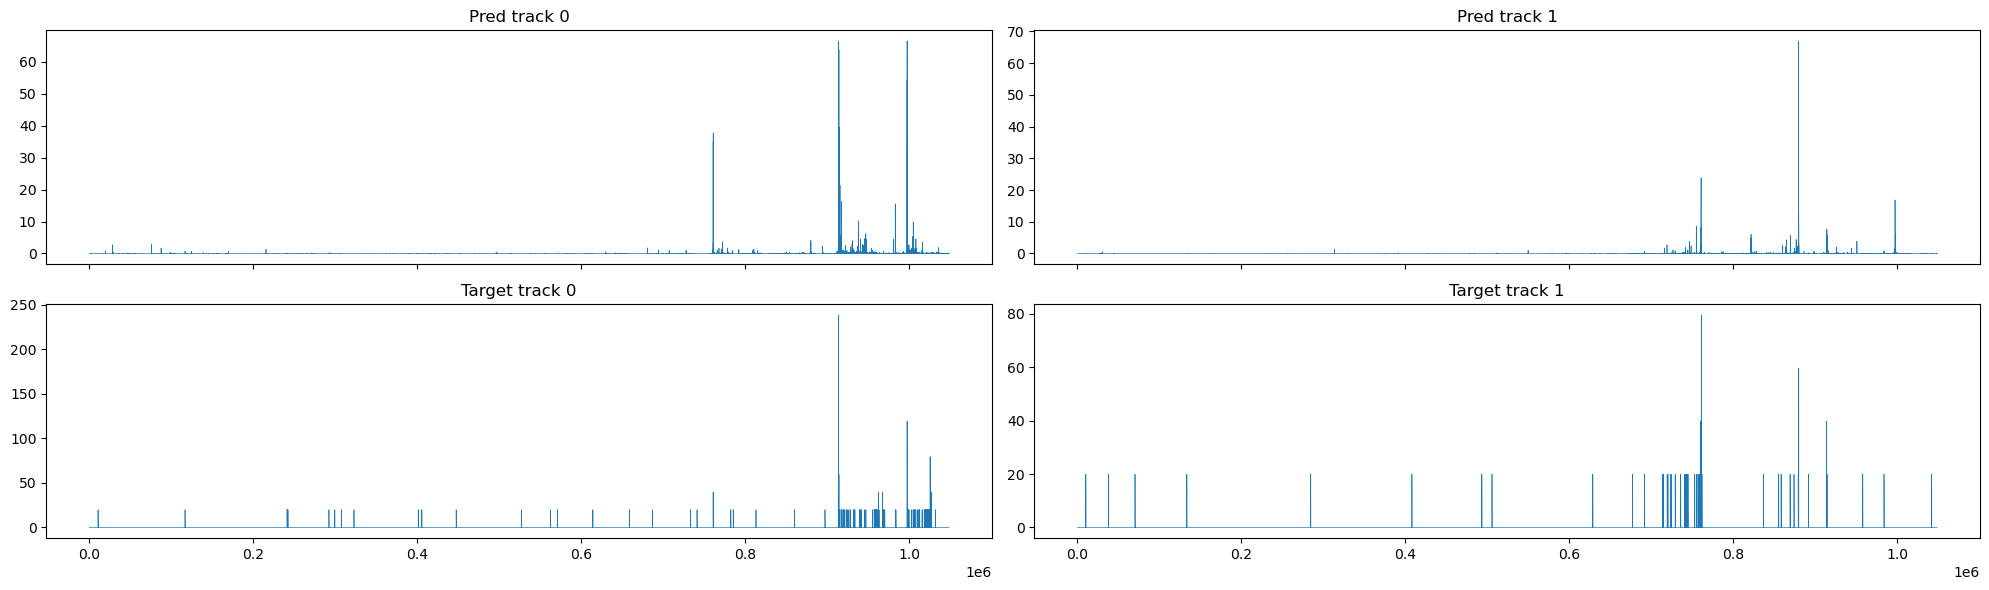

In [ ]:
import matplotlib.pyplot as plt
pred = out[1].squeeze(0).detach().cpu().float().numpy()  # (1048576, 2)
target = out[4].detach().cpu().float().numpy()           # (1048576, 2)

fig, axes = plt.subplots(2, 2, figsize=(20, 6), sharex=True)
for i in range(2):
    axes[0, i].plot(pred[:, i], lw=0.5)
    axes[0, i].set_title(f'Pred track {i}')
    axes[1, i].plot(target[:, i], lw=0.5)
    axes[1, i].set_title(f'Target track {i}')
plt.tight_layout()
plt.show()

In [ ]:
#yeah already seeming decent, maybe just learning promoters so far. 

In [ ]:
#let's ensure that none of the CAGE or DNasae data is nan? I kinda doubt it tho...

# wait potentially a new issue? if the values of A log is very negative this could be an issue?

In [12]:
#let's load the backbone we know is problematic
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
from evals.evals_utils_joint import Evals
ckpt_path = "/data1/lesliec/sarthak/caduceus/outputs/2026-04-19/21-58-28-647055/checkpoints/00-step=4000.ckpt"
evals = Evals(ckpt_path)
#now let's print
evals.backbone

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=None, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>


DNAEmbeddingModelStriped(
  (backbone): StripedMambaBackbone(
    (conv_block): ConvBlock(
      (norm): RMSBatchNorm1d()
      (act): GELU(approximate='none')
      (op): StandardizedConv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    )
    (global_down): DownsampleStack(
      (layers): ModuleList(
        (0): DownsampleLayer(
          (downres_increase): ConvBlock(
            (norm): RMSBatchNorm1d()
            (act): GELU(approximate='none')
            (op): StandardizedConv1d(128, 192, kernel_size=(5,), stride=(1,), padding=(2,))
          )
          (downres_refine): ConvBlock(
            (norm): RMSBatchNorm1d()
            (act): GELU(approximate='none')
            (op): StandardizedConv1d(192, 192, kernel_size=(5,), stride=(1,), padding=(2,))
          )
          (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
        (1): DownsampleLayer(
          (downres_increase): ConvBlock(
            (norm): RMSBatchNo

In [13]:
for hydra_block in evals.backbone.backbone.hydra_blocks:
    print(hydra_block)

HydraBlock(
  (mixer_norm): RMSNorm()
  (mixer): Hydra(
    (in_proj): Linear(in_features=512, out_features=4128, bias=False)
    (conv1d): Conv1d(3072, 3072, kernel_size=(7,), stride=(1,), padding=(3,), groups=3072)
    (act): SiLU()
    (fc_D): Linear(in_features=1024, out_features=16, bias=False)
    (norm): RMSNorm()
    (out_proj): Linear(in_features=1024, out_features=512, bias=False)
  )
  (mixer_dropout): Dropout(p=0.1, inplace=False)
)
HydraBlock(
  (mixer_norm): RMSNorm()
  (mixer): Hydra(
    (in_proj): Linear(in_features=512, out_features=4128, bias=False)
    (conv1d): Conv1d(3072, 3072, kernel_size=(7,), stride=(1,), padding=(3,), groups=3072)
    (act): SiLU()
    (fc_D): Linear(in_features=1024, out_features=16, bias=False)
    (norm): RMSNorm()
    (out_proj): Linear(in_features=1024, out_features=512, bias=False)
  )
  (mixer_dropout): Dropout(p=0.1, inplace=False)
)
HydraBlock(
  (mixer_norm): RMSNorm()
  (mixer): Hydra(
    (in_proj): Linear(in_features=512, out_fea

In [14]:
hydra_block.mixer.A_log

Parameter containing:
tensor([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       device='cuda:0', requires_grad=True)

In [15]:
#ok that one seems fine?
for block in evals.backbone.backbone.hydra_blocks:
    print(block.mixer.A_log.min())

tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>)


In [ ]:
#ok at this point all the weights are just nan...

In [16]:
#let's find the previous step
ckpt_path = "/data1/lesliec/sarthak/caduceus/outputs/2026-04-19/21-58-28-647055/checkpoints/00-step=2000.ckpt"
evals = Evals(ckpt_path)

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=None, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>


In [17]:
for block in evals.backbone.backbone.hydra_blocks:
    print(block.mixer.A_log.min())

tensor(-0.2562, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.6895, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.4385, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.8529, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.3004, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.2327, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.1982, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.2350, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.3053, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.3431, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.2427, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-0.1638, device='cuda:0', grad_fn=<MinBackward1>)


In [22]:
from tqdm import tqdm
import torch
def check_item(item, idx):                                                                                                                                                                                                                                                                                                                           
    bad = []    
    # item is a tuple of tuples; flatten all tensors                                                                                                                                                                                                                                                                                                 
    def recurse(x, path):                                                                                                                                                                                                                                                                                                                            
        if isinstance(x, (tuple, list)):                                                                                                                                                                                                                                                                                                             
            for i, v in enumerate(x):                                                                                                                                                                                                                                                                                                                
                recurse(v, f"{path}[{i}]")
        elif isinstance(x, torch.Tensor):                                                                                                                                                                                                                                                                                                            
            if torch.isnan(x).any():
                bad.append(f"{path}: NaN")                                                                                                                                                                                                                                                                                                           
            if torch.isinf(x).any():
                bad.append(f"{path}: Inf")                                                                                                                                                                                                                                                                                                           
        elif x is None:
            bad.append(f"{path}: None")                                                                                                                                                                                                                                                                                                              
    recurse(item, "")
    if bad:                                                                                                                                                                                                                                                                                                                                          
        print(f"idx={idx}: {bad}")
    return len(bad) == 0                                                                                                                                                                                                                                                                                                                             
                                                                                                                                                                                                                                                                                                                                                       
n_bad = 0
for i in tqdm(range(len(evals.dataset))):                                                                                                                                                                                                                                                                                                                  
    item = evals.dataset[i]
    if not check_item(item, i):
        n_bad += 1
        print(f"idx={i}: {item}")

  0%|          | 10/19370 [00:30<16:14:27,  3.02s/it]


KeyboardInterrupt: 

In [ ]:
#we'll create a script to validate parallelizing it

# what if we just resume training and then reset the seed and hope it works?

In [2]:
#let's make sure that there's no nan here in the last checkpoint
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
from evals.evals_utils_joint import Evals
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2026-04-21/16-04-57-263895/checkpoints/00-step=6000.ckpt'
evals = Evals(ckpt_path)
out = evals(0)
print(torch.isnan(out[1]).any())

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=None, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>


/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


NameError: name 'torch' is not defined

In [7]:
import torch
evals.skip_softplus = True
out = evals(0)
print(torch.isnan(out[1]).any())

/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


tensor(False, device='cuda:0')


In [8]:
out

(None,
 tensor([[[1.0328e-03, 6.6054e-05],
          [9.4039e-04, 1.5845e-04],
          [2.6122e-04, 3.1509e-04],
          ...,
          [2.7187e-03, 7.7967e-04],
          [5.9286e-03, 2.3053e-04],
          [4.9175e-03, 6.2653e-04]]], device='cuda:0'),
 tensor([[0., 0., 0., 1., 0., 0.],
         [0., 1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0.],
         ...,
         [0., 0., 0., 1., 0., 0.],
         [1., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0.]]),
 tensor([[0.0613, 0.0000],
         [0.0613, 0.0000],
         [0.0613, 0.0000],
         ...,
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000]]),
 tensor([[0., 0.],
         [0., 0.],
         [0., 0.],
         ...,
         [0., 0.],
         [0., 0.],
         [0., 0.]]))

In [10]:
for i in range(len(out)):
    if i == 0:
        continue
    print(f"out[{i}]: shape={out[i].shape}, dtype={out[i].dtype}, min={out[i].min().item()}, max={out[i].max().item()}")

out[1]: shape=torch.Size([1, 1048576, 2]), dtype=torch.float32, min=0.0, max=332.0
out[2]: shape=torch.Size([2097152, 6]), dtype=torch.float32, min=0.0, max=1.0
out[3]: shape=torch.Size([2097152, 2]), dtype=torch.float32, min=0.0, max=24.875
out[4]: shape=torch.Size([1048576, 2]), dtype=torch.float32, min=0.0, max=238.61778259277344


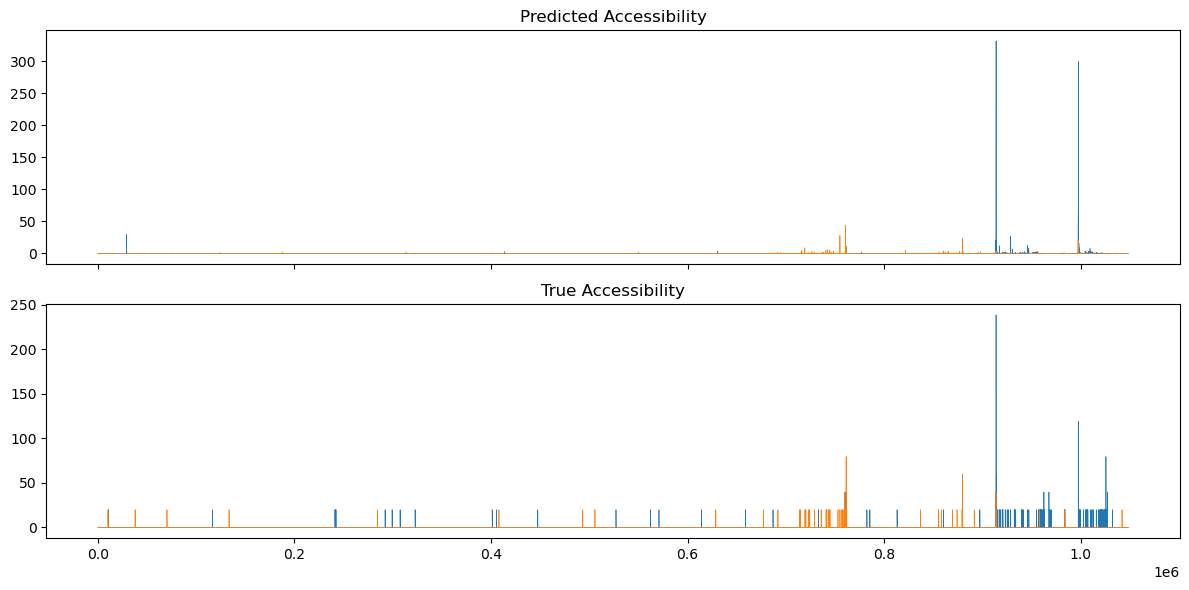

In [11]:
#let's plot it
import matplotlib.pyplot as plt
pred = out[1].squeeze(0).detach().cpu().float().numpy()
target = out[4].detach().cpu().float().numpy()
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(pred, linewidth=0.5)
axes[0].set_title('Predicted Accessibility')
axes[1].plot(target, linewidth=0.5)
axes[1].set_title('True Accessibility')
plt.tight_layout()
plt.show()

In [12]:
pred.shape

(1048576, 2)

# we ahve an updated mode, let's see how well it actually predicts

In [1]:
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
from evals.evals_utils_joint import Evals
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2026-04-24/23-01-02-587384/checkpoints/00-step=8000.ckpt'
evals = Evals(ckpt_path)
evals.skip_softplus = True

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=None, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>


/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


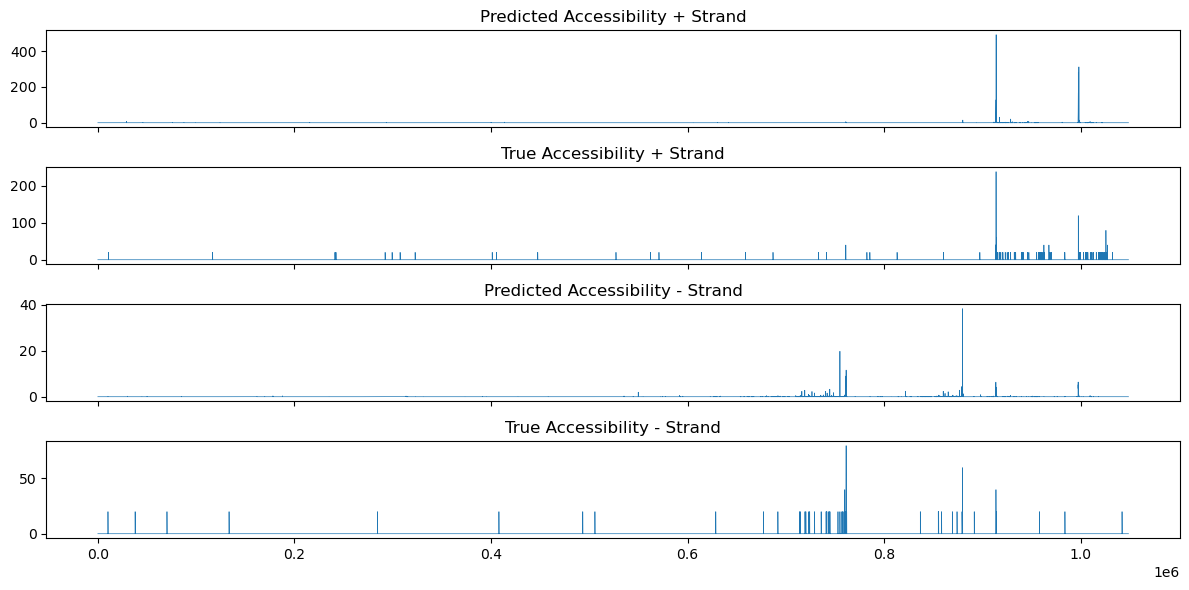

In [5]:
#let's now plot 3 of the outputs plus and - strands
import matplotlib.pyplot as plt
out = evals(0)
pred = out[1].squeeze(0).detach().cpu().float().numpy()
target = out[4].detach().cpu().float().numpy()
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
axes[0].plot(pred[:, 0], linewidth=0.5)
axes[0].set_title('Predicted Accessibility + Strand')
axes[1].plot(target[:, 0], linewidth=0.5)
axes[1].set_title('True Accessibility + Strand')
axes[2].plot(pred[:, 1], linewidth=0.5)
axes[2].set_title('Predicted Accessibility - Strand')
axes[3].plot(target[:, 1], linewidth=0.5)
axes[3].set_title('True Accessibility - Strand')
plt.tight_layout()
plt.show()

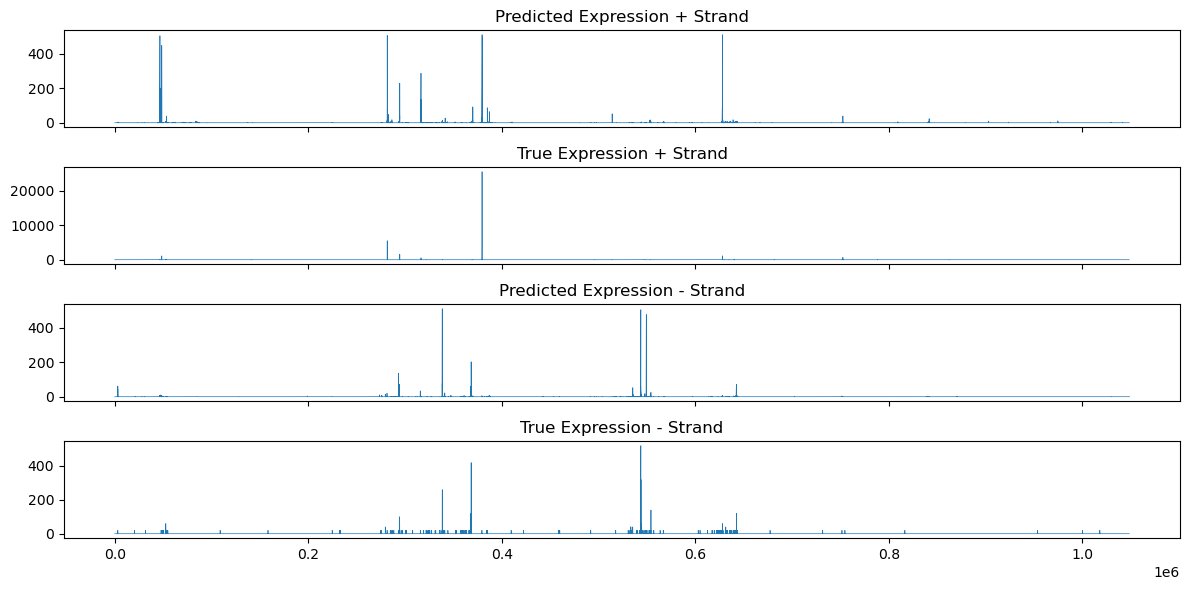

In [6]:
#surprisingly decent, lots of these random spikes in true expression, is that expected??
out = evals(100)
pred = out[1].squeeze(0).detach().cpu().float().numpy()
target = out[4].detach().cpu().float().numpy()
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
axes[0].plot(pred[:, 0], linewidth=0.5)
axes[0].set_title('Predicted Expression + Strand')
axes[1].plot(target[:, 0], linewidth=0.5)
axes[1].set_title('True Expression + Strand')
axes[2].plot(pred[:, 1], linewidth=0.5)
axes[2].set_title('Predicted Expression - Strand')
axes[3].plot(target[:, 1], linewidth=0.5)
axes[3].set_title('True Expression - Strand')
plt.tight_layout()
plt.show()

In [8]:
#well see this is problematic lmao! 20000, this is almost certainly a blacklist region... we should probalby process the CAGE like we did the other types to downplay blacklisted regions...
#let's calculate poisson loss between them
import torch.nn.functional as F
import torch
pred_tensor = torch.from_numpy(pred).float()
target_tensor = torch.from_numpy(target).float()
poisson_loss = F.poisson_nll_loss(pred_tensor, target_tensor, log_input=False)
print(f"Poisson Loss: {poisson_loss.item()}")

Poisson Loss: -0.24413500726222992


In [9]:
target.max()

25452.564

In [10]:
#loss not huge? lmao let's try reduction none
poisson_loss_none = F.poisson_nll_loss(pred_tensor, target_tensor, log_input=False, reduction='none')
print(f"Poisson Loss (none): {poisson_loss_none}")

Poisson Loss (none): tensor([[5.7719e-06, 4.0064e-05],
        [1.5690e-05, 4.5399e-05],
        [2.4301e-05, 2.7536e-05],
        ...,
        [4.4432e-04, 3.9212e-04],
        [4.4432e-04, 2.4540e-04],
        [3.1509e-04, 2.6122e-04]])


In [11]:
poisson_loss_none.min(), poisson_loss_none.max()

(tensor(-158269.3594), tensor(509.8490))

In [13]:
#let's see if this is truly a blacklisted region lol. But this would defintiely be hit by exteme clip and things like that
import numpy as np
unmappable_file: str = '/data1/lesliec/sarthak/data/borzoi/umap.npz'
blacklist_file: str = '/data1/lesliec/sarthak/data/borzoi/blacklist.npz'

# with np.load(genome_seq_file) as data:
#     genome = {key: np.array(data[key]) for key in data}
        
with np.load(blacklist_file) as d:
    blacklist = {key: np.array(d[key]) for key in d}
with np.load(unmappable_file) as d:
    unmappable = {key: np.array(d[key]) for key in d}


In [14]:
#now let's find the start and stop elements
index = 100 % len(evals.dataset.sequences)
index

100

In [15]:
evals.dataset.sequences.iloc[index]

0       chr19
1    54280007
2    54411079
3        test
Name: 100, dtype: object

In [17]:
#now get the blacklist and unmappable regions for this sequence
chrom,start,stop,_ = evals.dataset.sequences.iloc[index]
#now extend start and stop so that stop-start=2^21
extension = 2**20 - (stop - start)
start -= extension // 2
stop += extension // 2
print(f"Extended region: {chrom}:{start}-{stop}")
print(stop-start)

Extended region: chr19:53821255-54869831
1048576


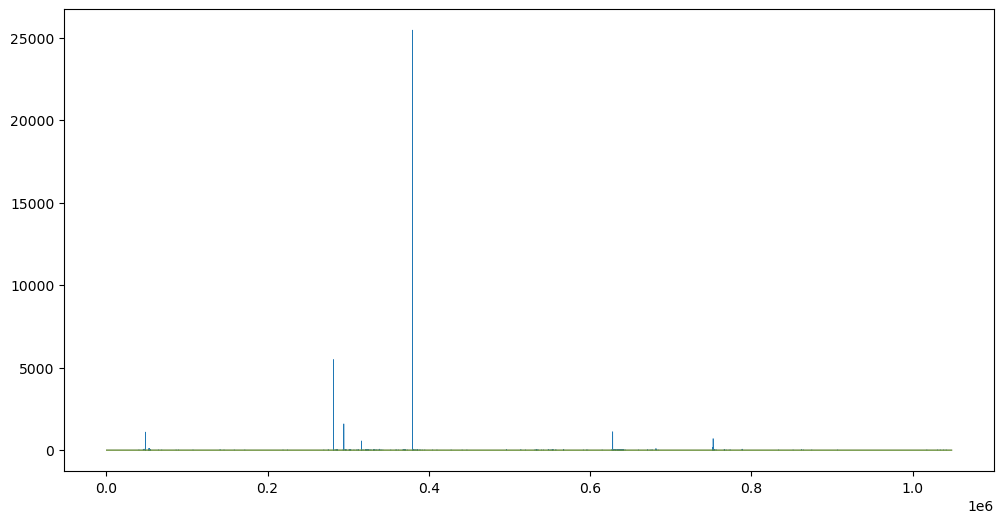

In [24]:
#now let's plot again
#make large fig size
plt.subplots(figsize=(12, 6), sharex=True)
plt.plot(target[:, 0], linewidth=0.5)
plt.plot(blacklist[chrom][start:stop], linewidth=0.5)
plt.plot(unmappable[chrom][start:stop], linewidth=0.5)

In [26]:
blacklist[chrom][start:stop].max(), blacklist[chrom][start:stop].min(), unmappable[chrom][start:stop].max(), unmappable[chrom][start:stop].min(), blacklist[chrom][start:stop].sum(), unmappable[chrom][start:stop].sum()

(1, 0, 1, 0, 6665, 115366)

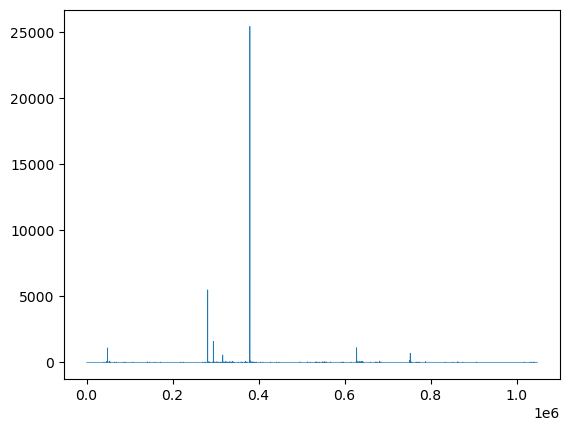

In [ ]:
#lots of unamppable regions in here, blacklist not so much
#let's multiply target by unmappable
plt.plot(target[:,0] * (1-unmappable[chrom][start:stop]) * (1-blacklist[chrom][start:stop]), linewidth=0.5)

/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


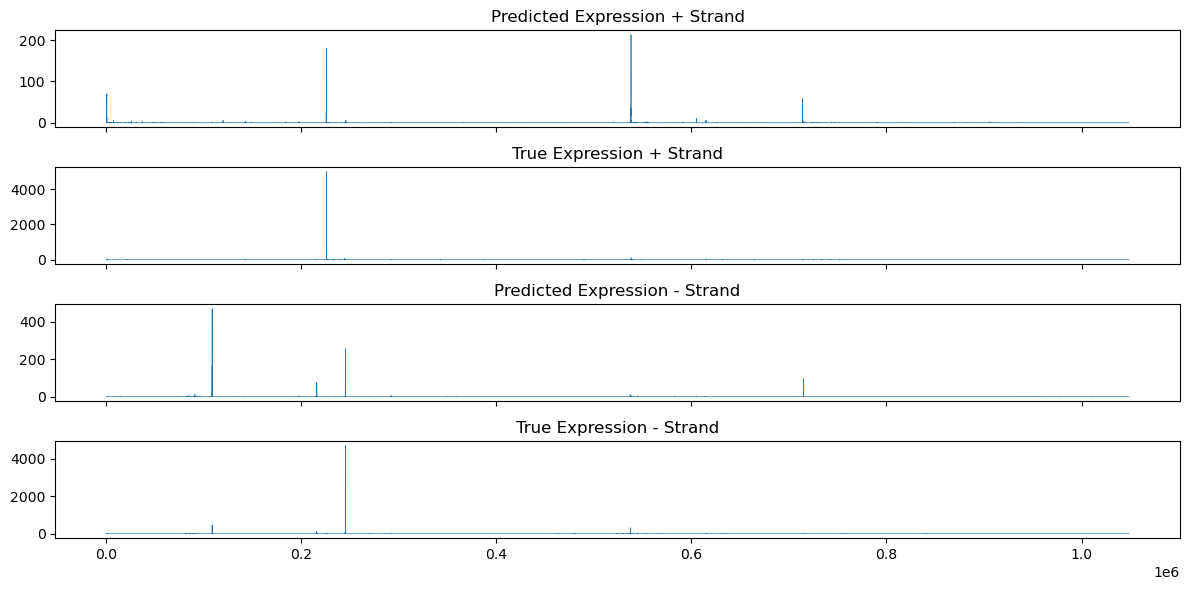

In [ ]:
#let's look at some more values
out = evals(10000)
pred = out[1].squeeze(0).detach().cpu().float().numpy()
target = out[4].detach().cpu().float().numpy()
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
axes[0].plot(pred[:, 0], linewidth=0.5)
axes[0].set_title('Predicted Expression + Strand')
axes[1].plot(target[:, 0], linewidth=0.5)
axes[1].set_title('True Expression + Strand')
axes[2].plot(pred[:, 1], linewidth=0.5)
axes[2].set_title('Predicted Expression - Strand')
axes[3].plot(target[:, 1], linewidth=0.5)
axes[3].set_title('True Expression - Strand')
plt.tight_layout()
plt.show()
#clearly it is not yet there 

In [31]:
#we can also compare between cell types
len(evals.dataset.sequences)

1937

/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


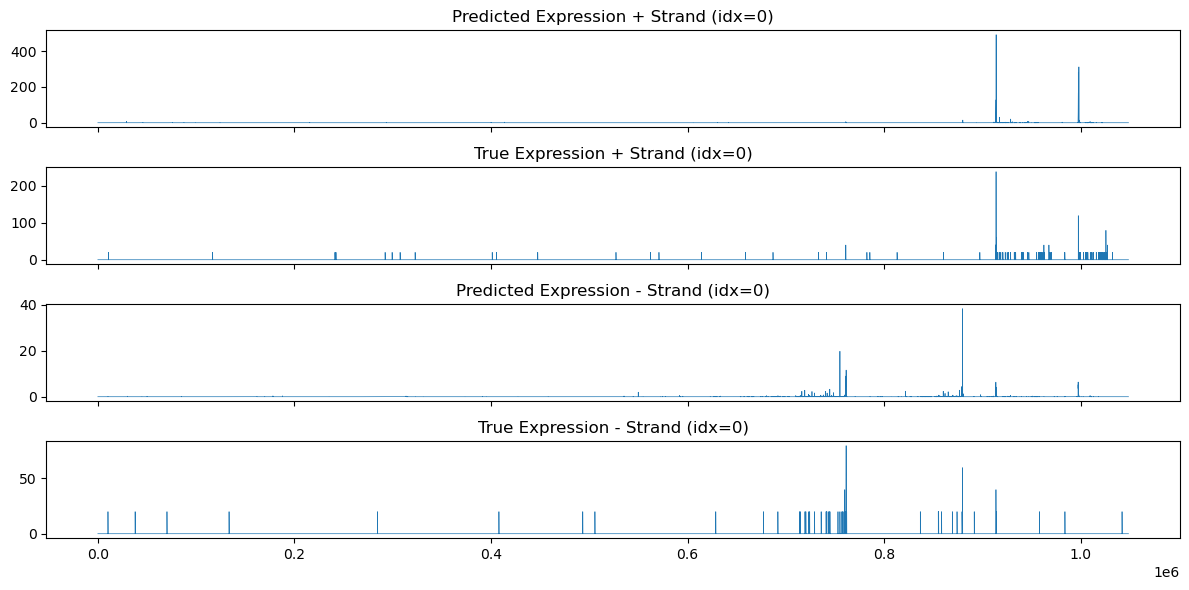

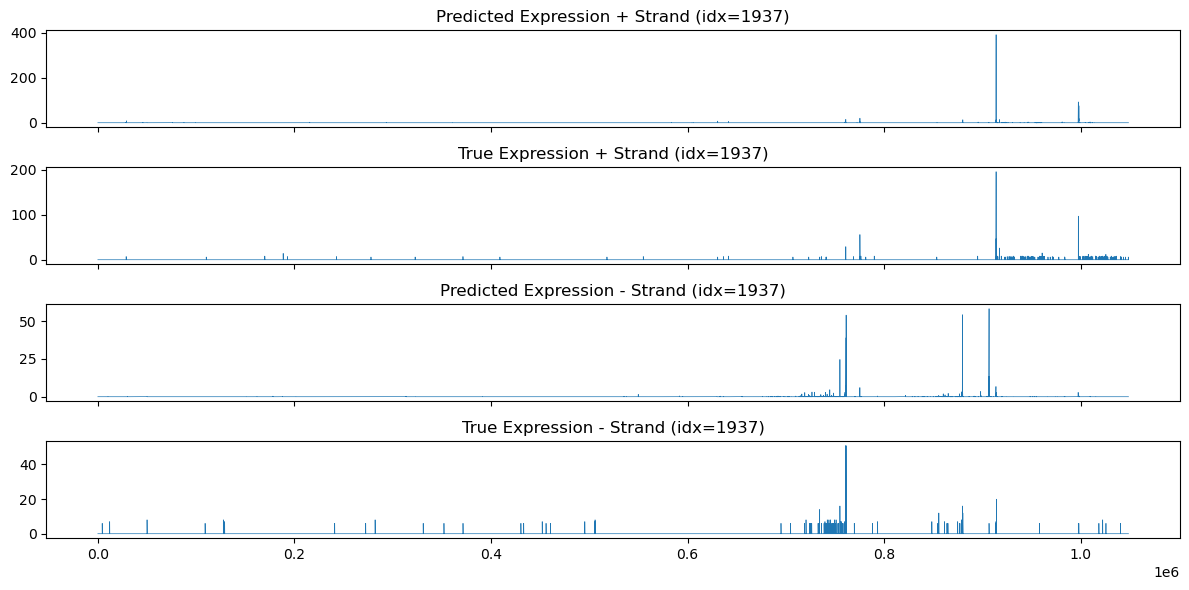

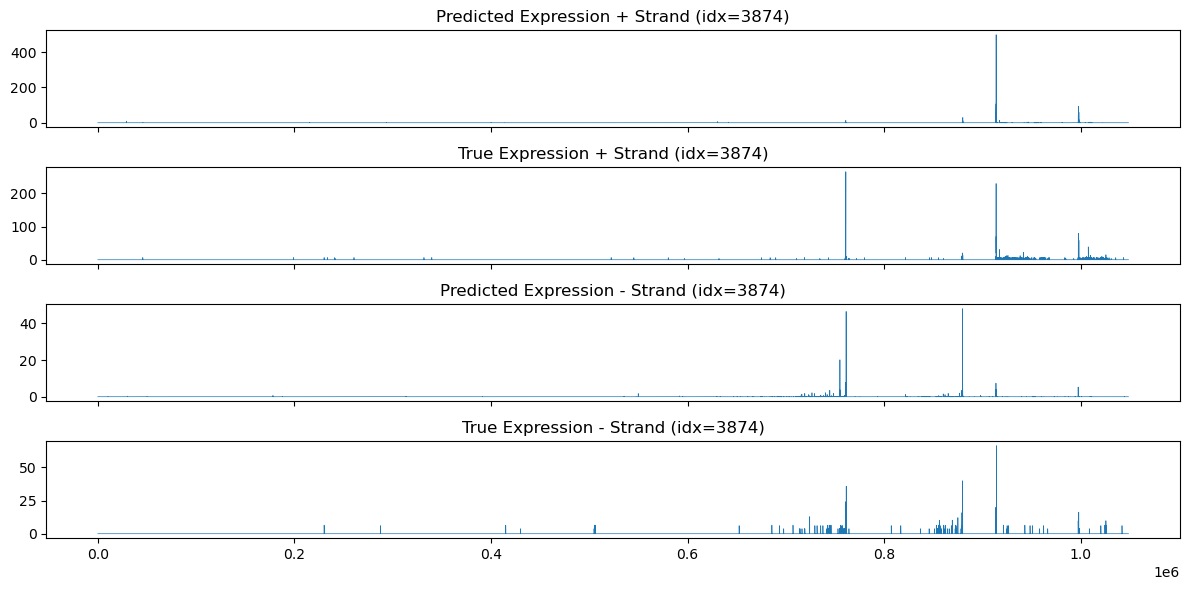

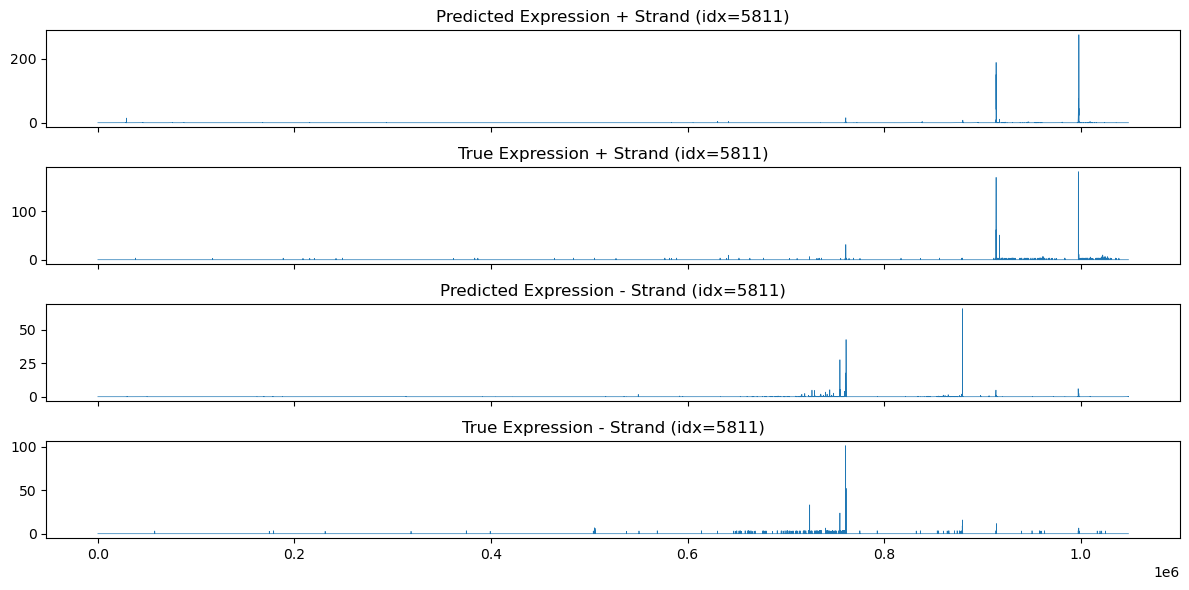

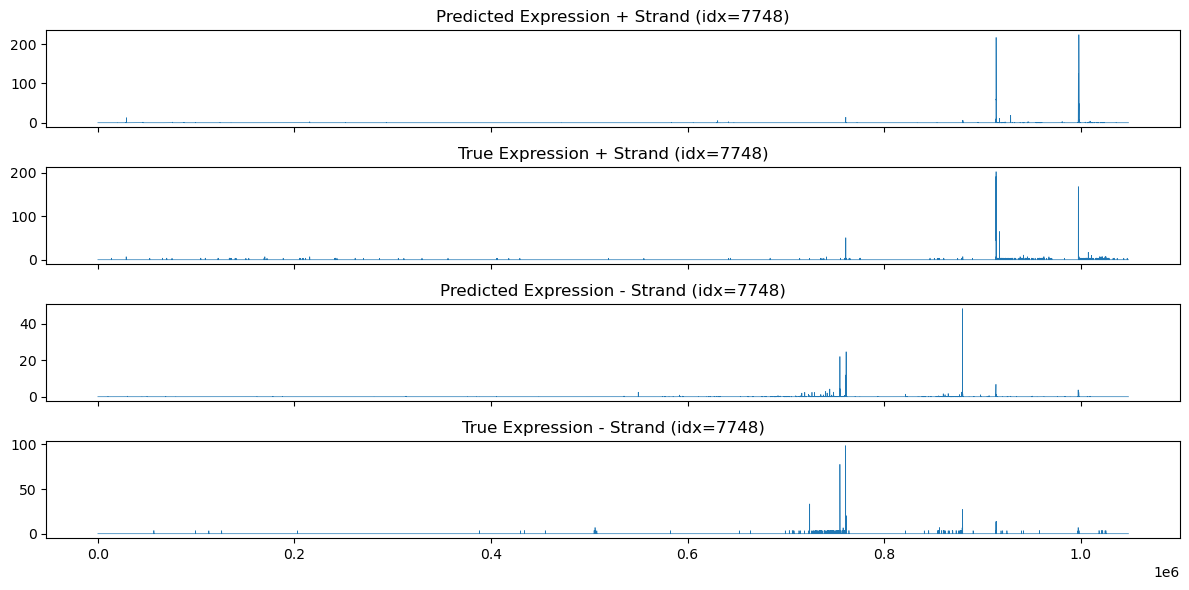

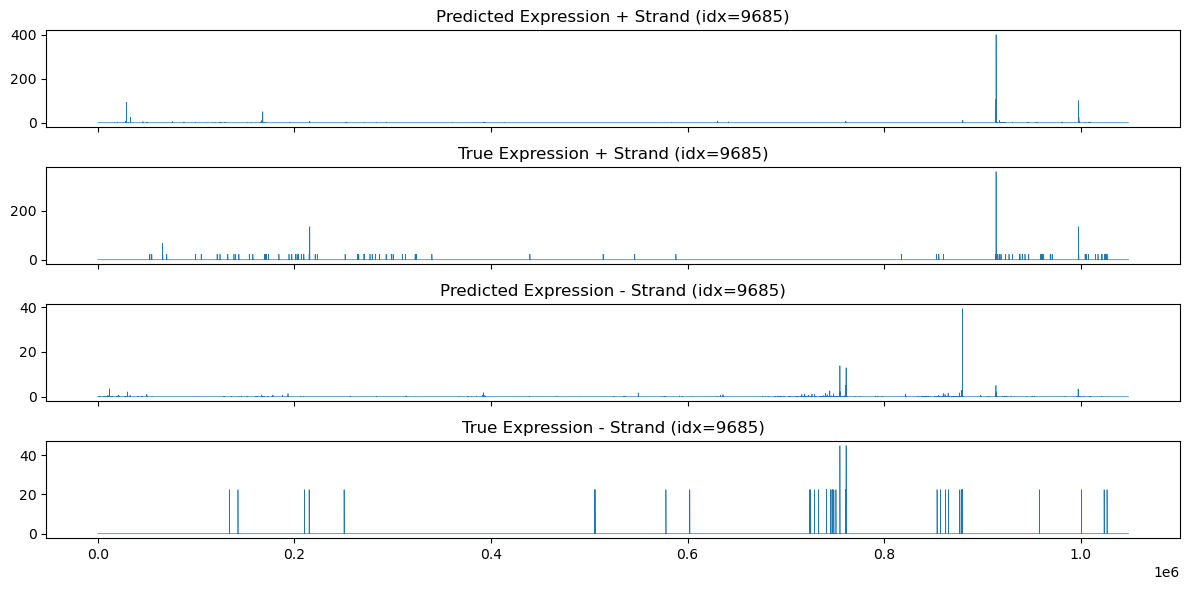

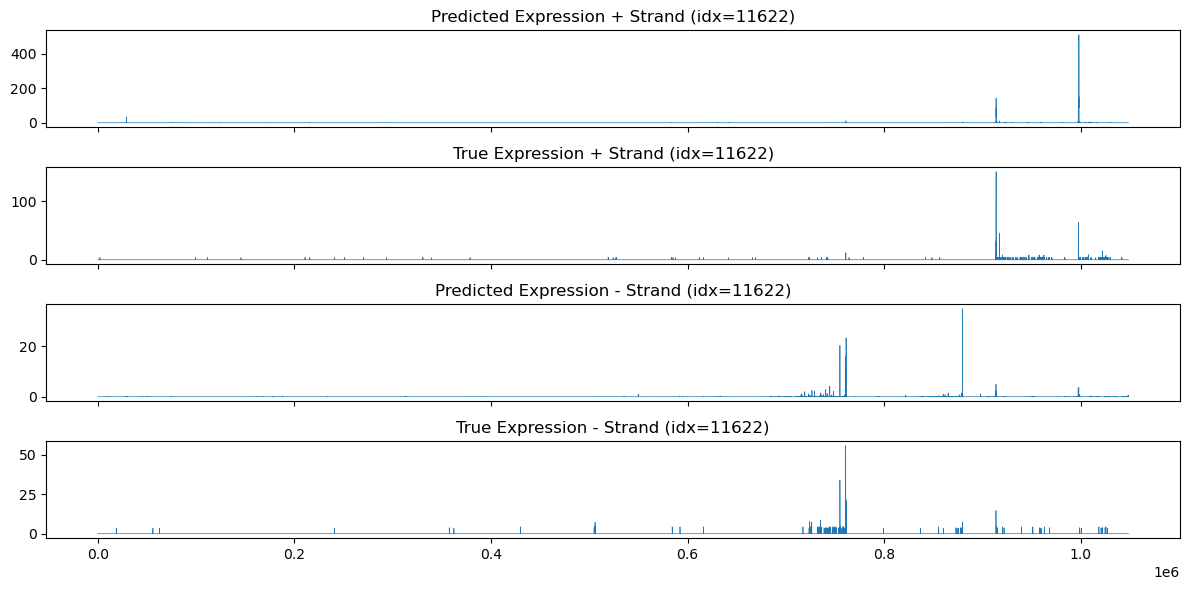

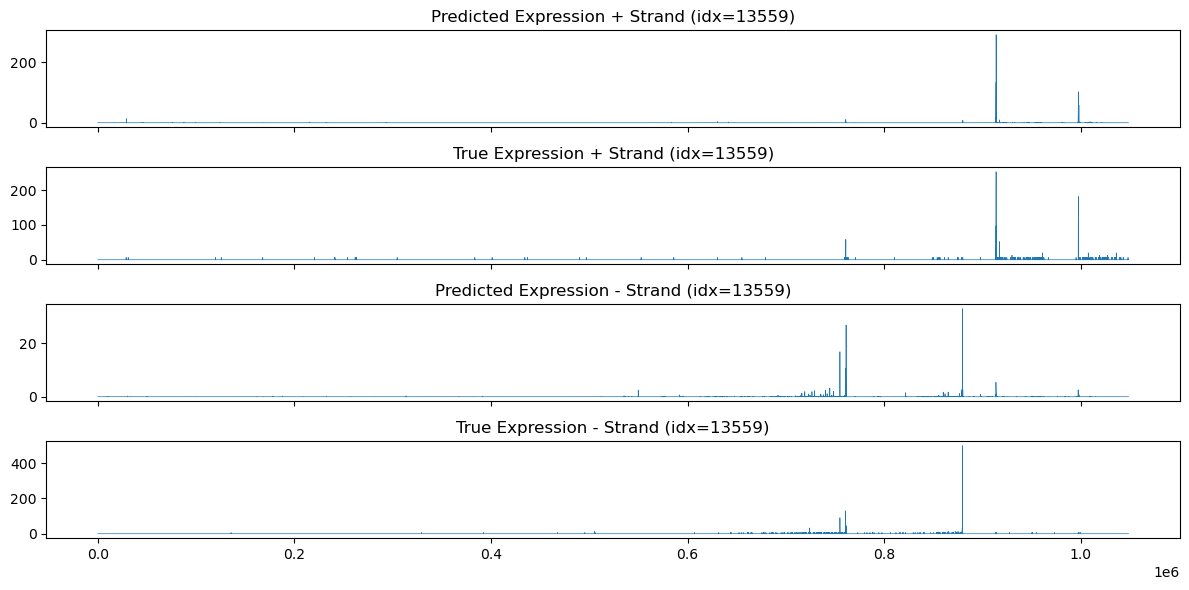

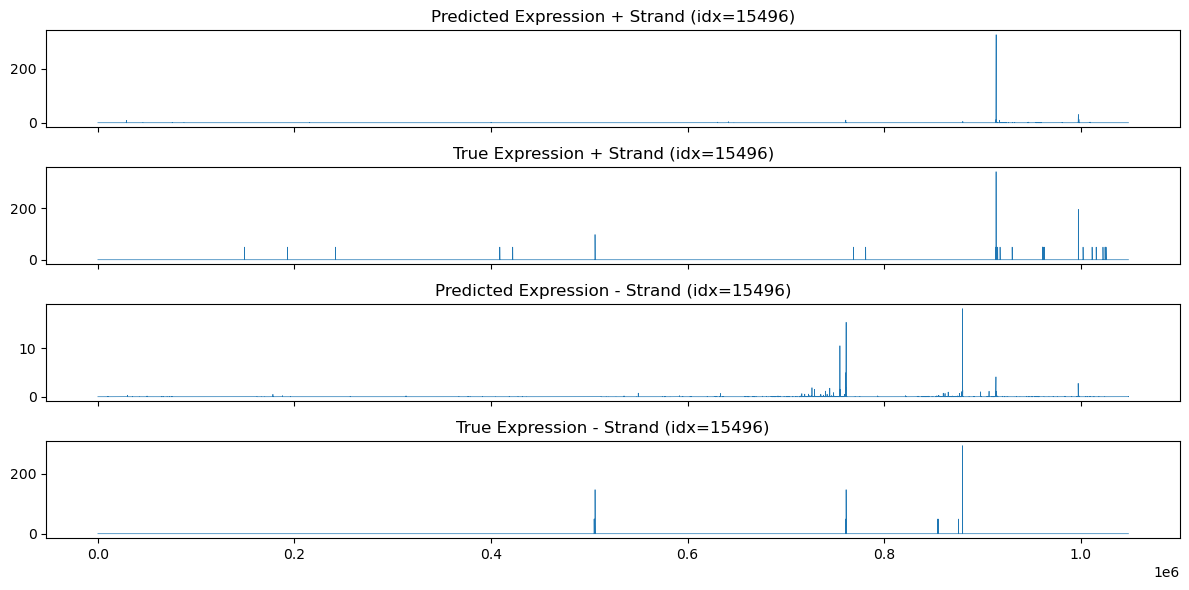

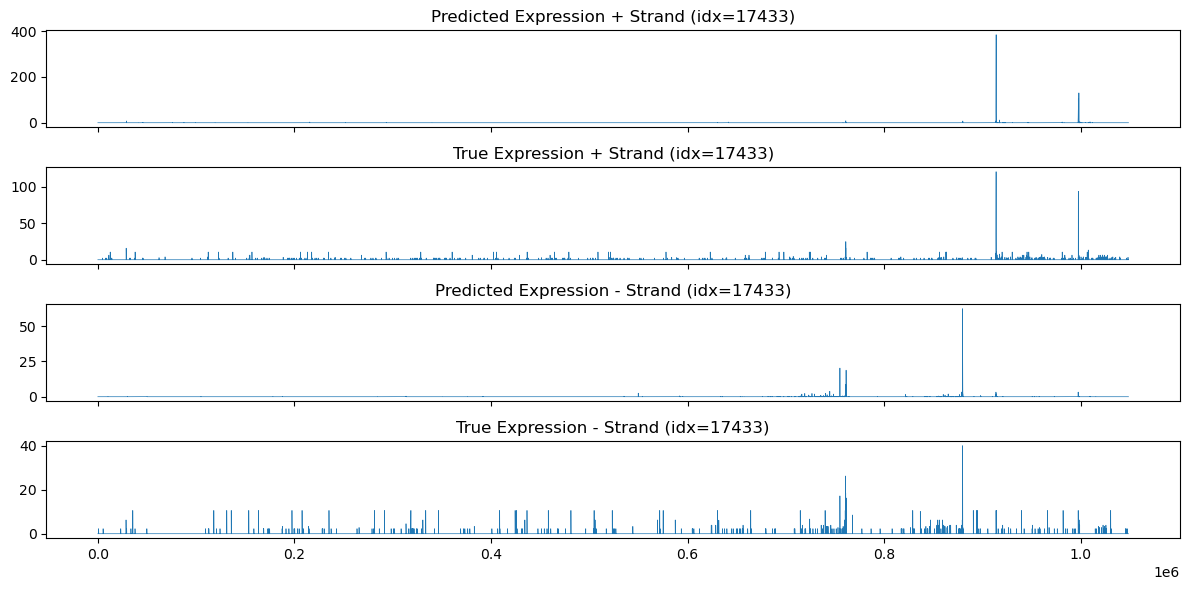

In [ ]:
#so 0, 1937, 1937*2 etc. will show it to us, let's plot it
for i in range(0, len(evals.dataset), 1937):
    out = evals(i)
    pred = out[1].squeeze(0).detach().cpu().float().numpy()
    target = out[4].detach().cpu().float().numpy()
    fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(pred[:, 0], linewidth=0.5)
    axes[0].set_title(f'Predicted Expression + Strand (idx={i})')
    axes[1].plot(target[:, 0], linewidth=0.5)
    axes[1].set_title(f'True Expression + Strand (idx={i})')
    axes[2].plot(pred[:, 1], linewidth=0.5)
    axes[2].set_title(f'Predicted Expression - Strand (idx={i})')
    axes[3].plot(target[:, 1], linewidth=0.5)
    axes[3].set_title(f'True Expression - Strand (idx={i})')
    plt.tight_layout()
    plt.show()

/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


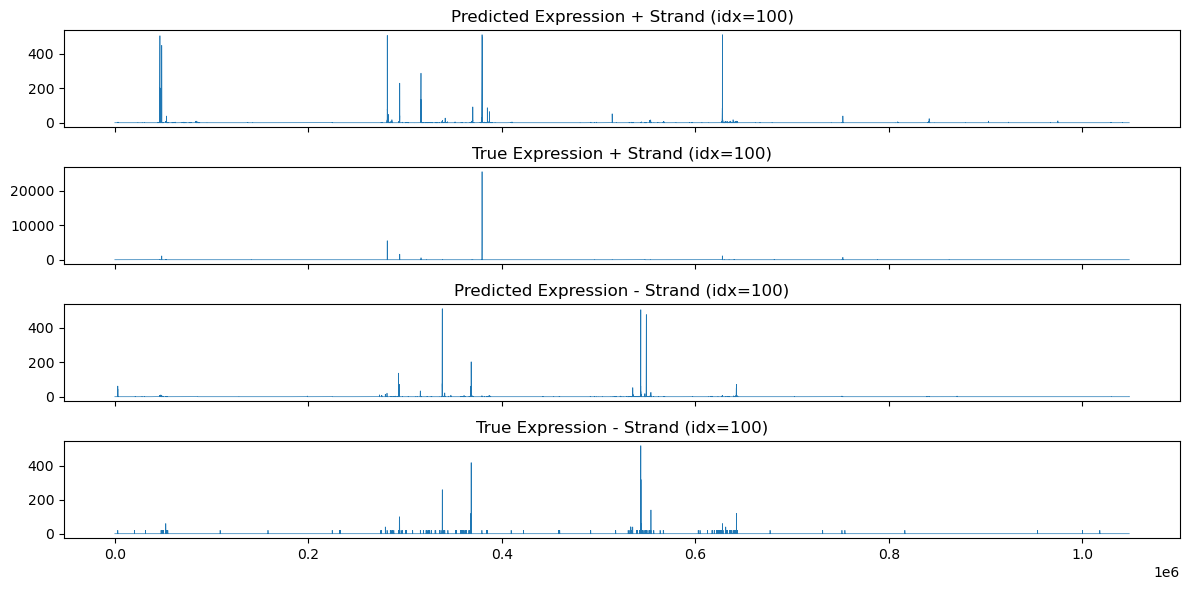

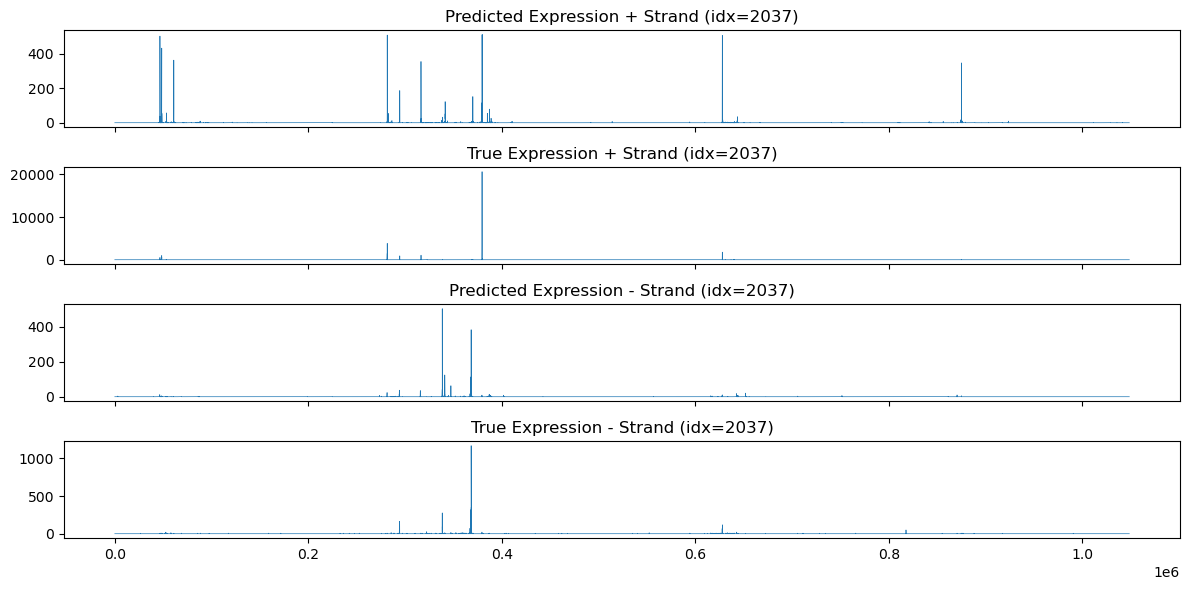

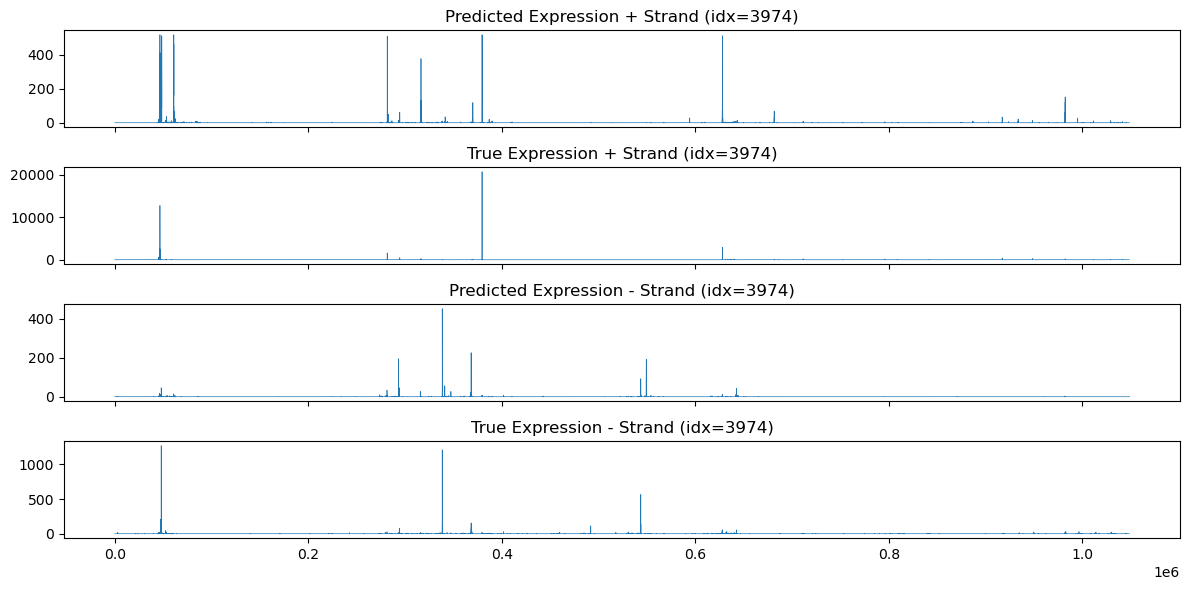

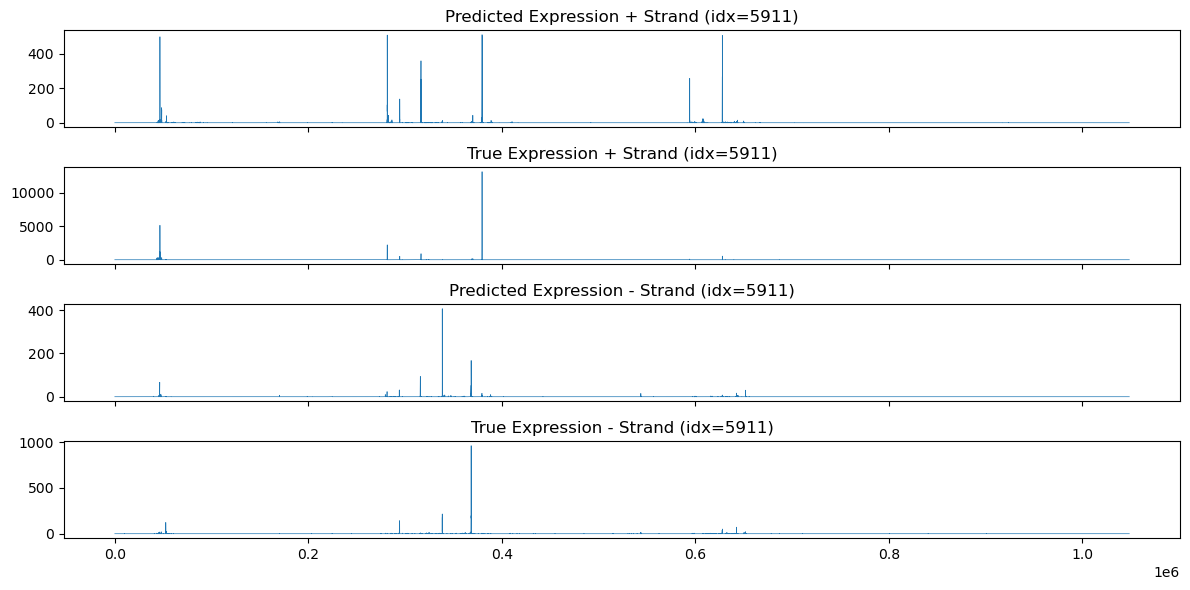

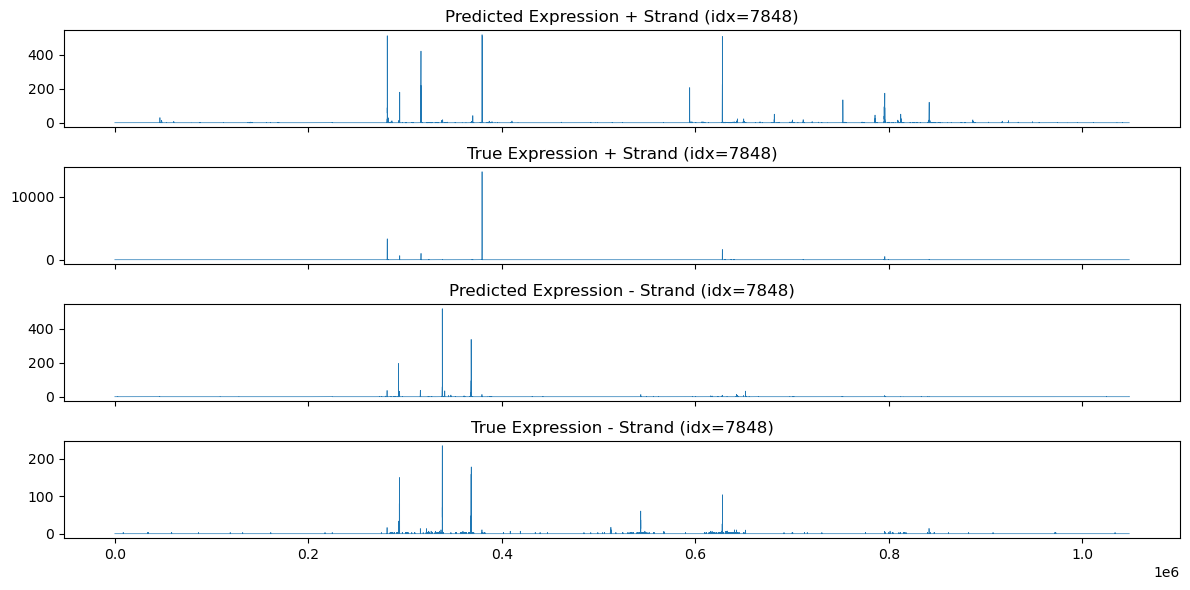

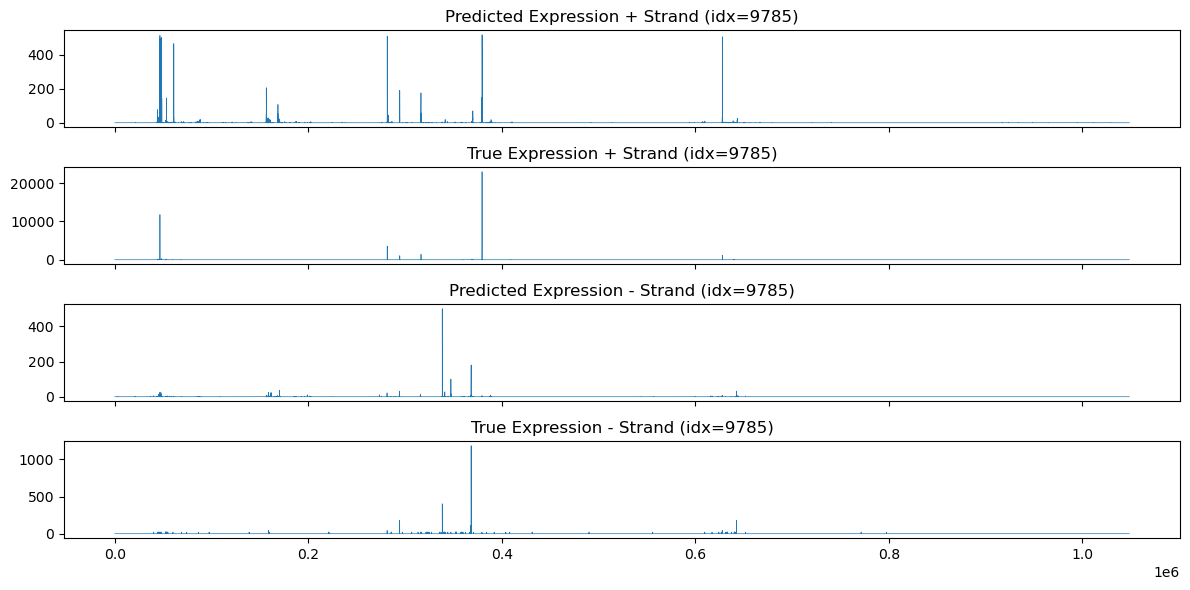

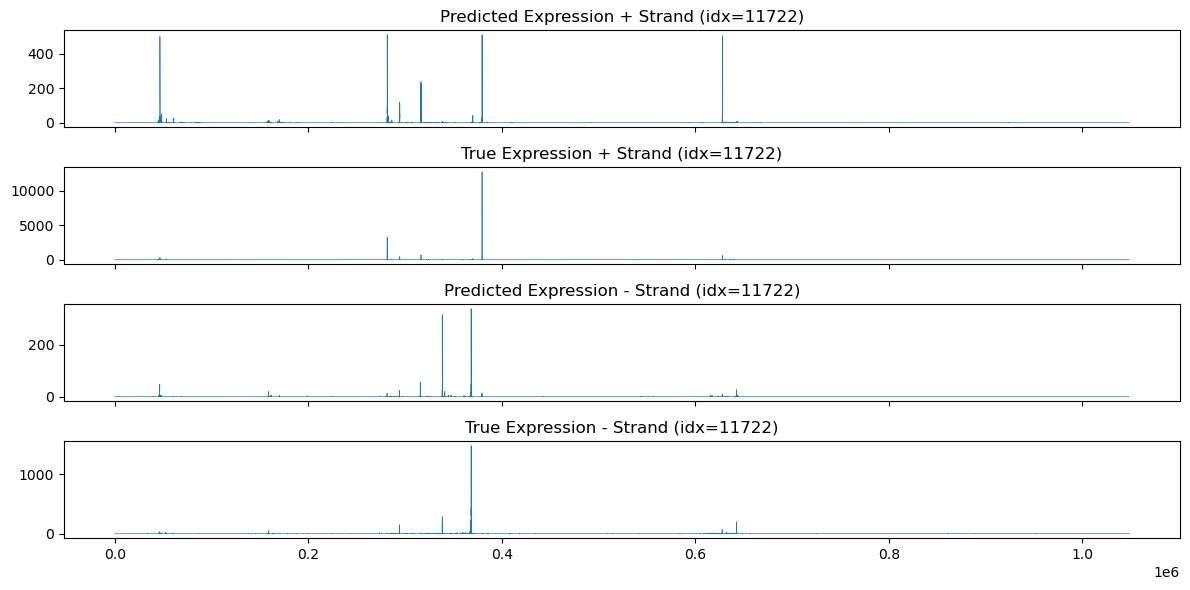

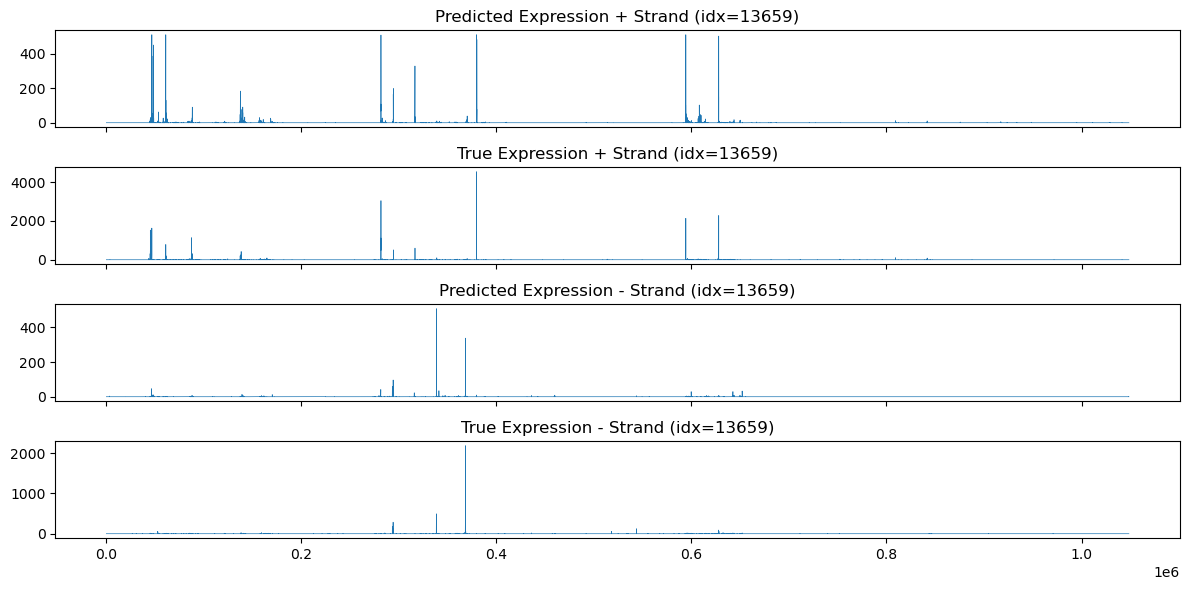

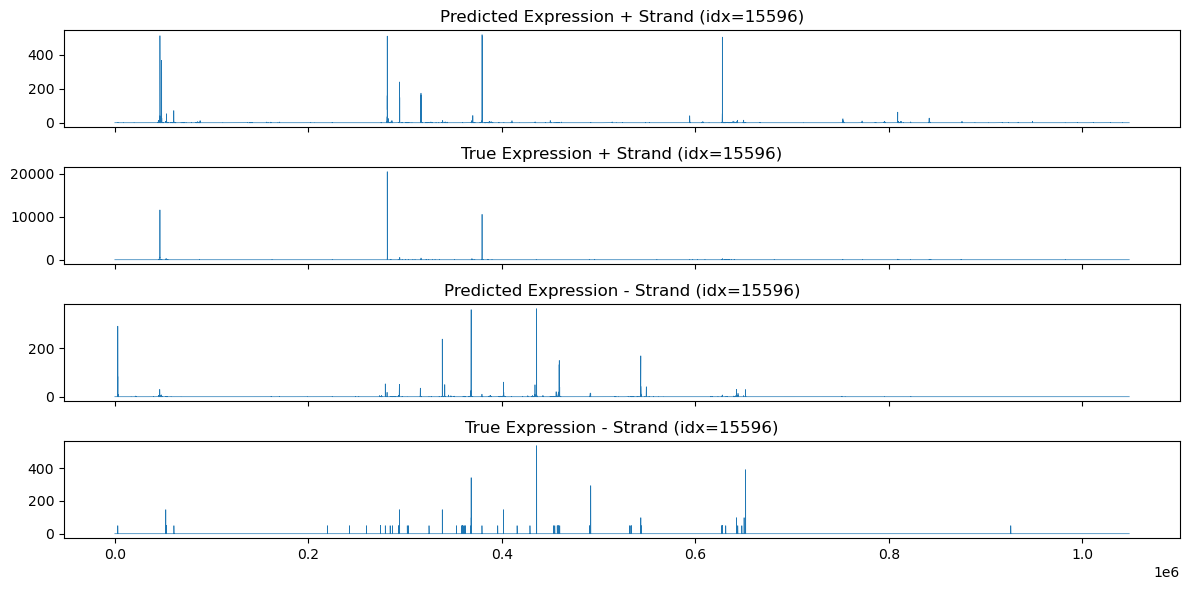

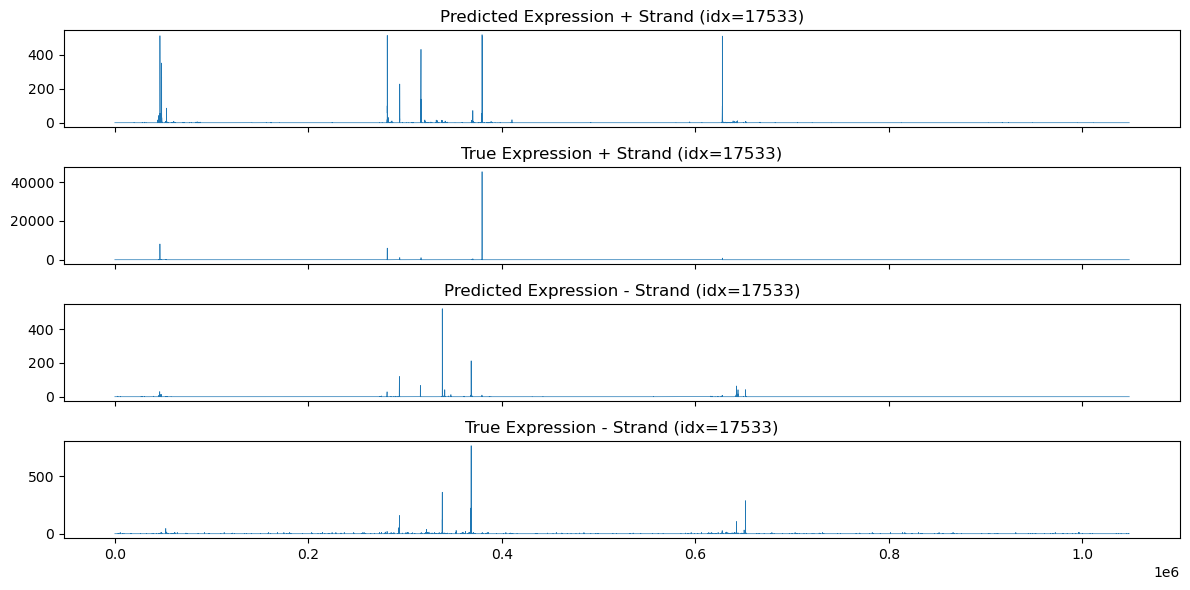

In [34]:
#let's do one more
#so 0, 1937, 1937*2 etc. will show it to us, let's plot it
for i in range(100, len(evals.dataset), 1937):
    out = evals(i)
    pred = out[1].squeeze(0).detach().cpu().float().numpy()
    target = out[4].detach().cpu().float().numpy()
    fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(pred[:, 0], linewidth=0.5)
    axes[0].set_title(f'Predicted Expression + Strand (idx={i})')
    axes[1].plot(target[:, 0], linewidth=0.5)
    axes[1].set_title(f'True Expression + Strand (idx={i})')
    axes[2].plot(pred[:, 1], linewidth=0.5)
    axes[2].set_title(f'Predicted Expression - Strand (idx={i})')
    axes[3].plot(target[:, 1], linewidth=0.5)
    axes[3].set_title(f'True Expression - Strand (idx={i})')
    plt.tight_layout()
    plt.show()

In [ ]:
#many actual differences between cell types! prediction just not the best right now?

In [ ]:
#I think surprisingly good, and surprisingly cellt ype specific! 